<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/Quick_Start_Quantum_Metal_Headless_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Metal quick start, headless Colab workflow with PHIDL-smoothed GDS export

This notebook completes the quick start tutorial from the Quantum Metal repository and makes it fully compatible to run in Google Colab without the GUI.

Run Cell 01 first. If Colab restarts, continue with Cell 02 through Cell 08 in order. The final cell writes `/content/quick_start_final_layout.gds` and renders the exported GDS inline.


## Cell 01: qm_quick_start_cell_01_setup.py


In [ ]:
"""
This script demonstrates a headless computational stack suitable for quantum hardware engineering
and Electronic Design Automation (EDA) workflows using Quantum Metal, PHIDL, GDSTK, and CuPy.

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)
"""

import os
import subprocess
import sys
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

FORCE_CLEAN_INSTALL: Final[bool] = False
RESTART_AFTER_INSTALL: Final[bool] = True
INSTALL_SENTINEL: Final[Path] = Path("/content/.qm_headless_colab_stack")

QT_QPA_PLATFORM: Final[str] = "offscreen"
MPLBACKEND: Final[str] = "Agg"

BINARY_FOUNDATION_PACKAGES: Final[list[str]] = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.14.1",
    "matplotlib==3.8.4",
    "h5py==3.11.0",
]

EDA_PACKAGES: Final[list[str]] = [
    "gdstk>=0.9.61,<1.0.0",
    "shapely>=2.0.0,<3.0.0",
    "ezdxf>=1.2.0,<2.0.0",
    "phidl>=1.7.2,<2.0.0",
    "networkx>=2.8",
    "pint>=0.20",
    "addict>=2.4.0",
    "pyyaml>=6.0.1",
    "descartes>=1.1",
    "jedi>=0.19.1",
]

GPU_PACKAGES: Final[list[str]] = [
    "cupy-cuda12x>=13.0.0,<14.0.0",
]

os.environ["QT_QPA_PLATFORM"] = QT_QPA_PLATFORM
os.environ["MPLBACKEND"] = MPLBACKEND


def run_command(command: list[str]) -> None:
    """Execute a synchronous subprocess command and raise an exception upon failure."""
    print(f"Executing: {' '.join(command)}")
    subprocess.check_call(command)


def purge_loaded_modules(target_modules: tuple[str, ...]) -> None:
    """Unload specific modules from the system registry to prevent binary conflicts."""
    for module in list(sys.modules.keys()):
        if any(module == target or module.startswith(f"{target}.") for target in target_modules):
            del sys.modules[module]


def install_stack() -> None:
    """Install a coherent compiled package stack specifically tailored for the notebook."""
    target_binaries: tuple[str, ...] = ("numpy", "pandas", "scipy", "matplotlib", "h5py")

    purge_loaded_modules(target_binaries)

    run_command([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "wheel", "setuptools"])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--force-reinstall", "--no-cache-dir", "--prefer-binary",
        *BINARY_FOUNDATION_PACKAGES
    ])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--no-cache-dir", "--prefer-binary",
        *EDA_PACKAGES, *GPU_PACKAGES
    ])


if FORCE_CLEAN_INSTALL or INSTALL_SENTINEL.exists() == False:
    install_stack()
    INSTALL_SENTINEL.write_text("installed\n", encoding="utf-8")
    print("Dependency installation concluded successfully.")

    if RESTART_AFTER_INSTALL:
        print("Restarting the runtime environment gracefully to apply changes.")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("Installation sentinel detected. Proceeding with execution.")

####
"""Import the scientific stack after the install-time runtime restart."""

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
os.environ.setdefault("MPLBACKEND", "Agg")

try:
    import matplotlib as mpl

    mpl.use("Agg", force=True)
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
except ValueError as abi_error:
    raise RuntimeError(
        "NumPy/Pandas ABI mismatch remains. Run cell 1 in a fresh runtime, "
        "allow the restart, and then continue from this cell."
    ) from abi_error

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_CUPY_WHEN_AVAILABLE: Final[bool] = True
MPL_DPI: Final[int] = 250

mpl.rcParams["figure.dpi"] = MPL_DPI

cp = None
USING_CUPY = False
CUPY_IMPORT_ERROR = None

if USE_CUPY_WHEN_AVAILABLE:
    try:
        import cupy as cp_candidate

        GPU_COUNT = cp_candidate.cuda.runtime.getDeviceCount()
        USING_CUPY = GPU_COUNT > 0
        cp = cp_candidate if USING_CUPY else None
    except Exception as error:  # noqa: BLE001
        CUPY_IMPORT_ERROR = error

XP = cp if USING_CUPY and cp is not None else np


def to_numpy(array: Any) -> np.ndarray:
    """Return a NumPy array from a NumPy or CuPy object."""
    if USING_CUPY and cp is not None:
        return cp.asnumpy(array)
    return np.asarray(array)


def get_gpu_name() -> str:
    """Return the active CUDA device name when CuPy can access a GPU."""
    if not USING_CUPY or cp is None:
        return "CPU fallback"

    properties = cp.cuda.runtime.getDeviceProperties(0)
    name = properties["name"]
    if isinstance(name, bytes):
        return name.decode("utf-8")
    return str(name)


print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Matplotlib backend: {mpl.get_backend()}")

if USING_CUPY:
    print(f"CuPy version: {cp.__version__}")
    print(f"CUDA device: {get_gpu_name()}")
else:
    print("CuPy GPU backend unavailable. NumPy fallback is active.")
    if CUPY_IMPORT_ERROR is not None:
        print(f"CuPy import or CUDA check error: {CUPY_IMPORT_ERROR}")

####
"""Clone Quantum Metal, patch GUI-sensitive imports, and bind the local clone."""

import importlib
import os
import re
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_FRESH_QISKIT_METAL_CLONE: Final[bool] = True
QISKIT_METAL_REPO_URL: Final[str] = "https://github.com/qiskit-community/qiskit-metal"
QISKIT_METAL_ROOT: Final[Path] = Path("/content/qiskit-metal")


def run_command(command: list[str], cwd: Path | None = None) -> None:
    """Run a subprocess command and raise if it fails."""
    print("Running:", " ".join(command))
    subprocess.check_call(command, cwd=str(cwd) if cwd else None)


def clear_qiskit_metal_modules() -> None:
    """Remove cached qiskit_metal modules so patched files are reimported."""
    for module_name in list(sys.modules):
        if module_name == "qiskit_metal" or module_name.startswith("qiskit_metal."):
            del sys.modules[module_name]


def clone_qiskit_metal() -> None:
    """Clone the current Qiskit Metal repository into /content."""
    if USE_FRESH_QISKIT_METAL_CLONE and QISKIT_METAL_ROOT.exists():
        shutil.rmtree(QISKIT_METAL_ROOT)

    if not QISKIT_METAL_ROOT.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                QISKIT_METAL_REPO_URL,
                str(QISKIT_METAL_ROOT),
            ]
        )
    else:
        print(f"Using existing repository: {QISKIT_METAL_ROOT}")


def find_qiskit_metal_package() -> tuple[Path, Path]:
    """Return the import root and qiskit_metal package directory."""
    candidates = [
        QISKIT_METAL_ROOT / "qiskit_metal",
        QISKIT_METAL_ROOT / "src" / "qiskit_metal",
    ]

    for package_dir in candidates:
        if package_dir.exists():
            return package_dir.parent, package_dir

    raise FileNotFoundError(
        "Could not find qiskit_metal under /content/qiskit-metal. "
        f"Checked: {candidates}"
    )


def backup_file(path: Path) -> None:
    """Create a one-time backup of a file before patching it."""
    backup_path = path.with_name(f"{path.stem}__orig{path.suffix}")
    if path.exists() and not backup_path.exists():
        backup_path.write_text(path.read_text(encoding="utf-8"), encoding="utf-8")


def write_minimal_qiskit_metal_init(package_dir: Path) -> None:
    """Replace qiskit_metal.__init__ with a headless layout-only surface."""
    init_path = package_dir / "__init__.py"
    backup_file(init_path)
    minimal_init = textwrap.dedent(
        """
        # [colab] Headless, layout-only __init__ for Qiskit Metal.
        import logging as _logging

        try:
            from addict import Dict as Dict
        except Exception:
            from .toolbox_python.attr_dict import Dict

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False

        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
        """
    ).strip() + "\n"
    init_path.write_text(minimal_init, encoding="utf-8")


def patch_draw_package(package_dir: Path) -> None:
    """Guard draw.mpl imports so Qt/PySide does not load during imports."""
    draw_init = package_dir / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    backup_file(draw_init)
    text = draw_init.read_text(encoding="utf-8")
    text = re.sub(
        r"^\s*from\s+\.\s*import\s+mpl\s*$",
        "try:\n"
        "    from . import mpl\n"
        "except Exception as _draw_mpl_error:\n"
        "    print('[colab] draw.mpl disabled in headless mode:', _draw_mpl_error)\n",
        text,
        flags=re.MULTILINE,
    )
    text = re.sub(
        r"^\s*from\s+\.mpl\s+import[^\n]*$",
        "try:\n"
        "    from .mpl import render, figure_spawn\n"
        "except Exception as _draw_named_error:\n"
        "    print('[colab] draw.mpl named imports disabled:', _draw_named_error)\n"
        "    def render(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        text,
        flags=re.MULTILINE,
    )
    draw_init.write_text(text, encoding="utf-8")


def patch_renderers_package(package_dir: Path) -> None:
    """Keep renderer imports explicit to avoid Qt/MPL side effects."""
    renderer_init = package_dir / "renderers" / "__init__.py"
    if not renderer_init.exists():
        return

    backup_file(renderer_init)
    renderer_init.write_text(
        "# [colab] minimal renderers package. Use explicit renderer imports only.\n"
        "__all__ = []\n",
        encoding="utf-8",
    )


def setup_headless_qiskit_metal() -> Path:
    """Clone, patch, and bind Qiskit Metal to the current interpreter."""
    clone_qiskit_metal()
    import_root, package_dir = find_qiskit_metal_package()

    write_minimal_qiskit_metal_init(package_dir)
    patch_draw_package(package_dir)
    patch_renderers_package(package_dir)

    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

    existing_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = (
        str(import_root)
        if not existing_pythonpath
        else f"{import_root}:{existing_pythonpath}"
    )

    clear_qiskit_metal_modules()
    importlib.invalidate_caches()

    import qiskit_metal

    imported_from = Path(qiskit_metal.__file__).resolve()
    expected_root = package_dir.resolve()
    expected_init = expected_root / "__init__.py"
    if imported_from != expected_init:
        raise RuntimeError(
            "qiskit_metal imported from the wrong location. "
            f"Imported from {imported_from}; expected {expected_init}."
        )

    print("qiskit_metal from:", imported_from)
    return package_dir

QISKIT_METAL_PACKAGE_DIR = setup_headless_qiskit_metal()


Installation sentinel detected. Proceeding with execution.
NumPy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.8.4
Matplotlib backend: agg
CuPy GPU backend unavailable. NumPy fallback is active.
CuPy import or CUDA check error: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version
Running: git clone --depth 1 https://github.com/qiskit-community/qiskit-metal /content/qiskit-metal
qiskit_metal from: /content/qiskit-metal/src/qiskit_metal/__init__.py


## Cell 02: qm_quick_start_cell_02_headless_helpers.py


In [ ]:
"""Shared headless Quantum Metal helpers for the coherent quick-start notebook.

Paste this cell immediately after the setup cell has completed and the Colab
runtime has restarted.  It provides one shared design state, direct qgeometry
plotting, manual GDS export through GDSTK, and a GDS preview renderer.
"""

from collections.abc import Iterable, Sequence
from pathlib import Path
from typing import Any, Final

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import (
    GeometryCollection,
    LineString,
    MultiLineString,
    MultiPolygon,
    Polygon,
)

# =============================================================================
# CONTROL KNOBS
# =============================================================================

MPL_DPI: Final[int] = 250

FIGURE_SIZE: Final[tuple[float, float]] = (8.2, 6.2)
WIDE_FIGURE_SIZE: Final[tuple[float, float]] = (11.5, 6.2)
COMPARISON_FIGURE_SIZE: Final[tuple[float, float]] = (12.0, 5.0)

POLY_FACE_COLOR: Final[str] = "#1f77b4"
POLY_EDGE_COLOR: Final[str] = "#000000"
SUBTRACT_FACE_COLOR: Final[str] = "#f2f2f2"
SUBTRACT_EDGE_COLOR: Final[str] = "#4d4d4d"
PATH_COLOR: Final[str] = "#111111"
JUNCTION_COLOR: Final[str] = "#d62728"
PIN_COLOR: Final[str] = "#d62728"

POLY_ALPHA: Final[float] = 0.42
SUBTRACT_ALPHA: Final[float] = 0.75
PATH_ALPHA: Final[float] = 0.90
JUNCTION_ALPHA: Final[float] = 0.90

OUTLINE_WIDTH: Final[float] = 0.75
MIN_PATH_WIDTH_PT: Final[float] = 1.10
PATH_WIDTH_SCALE_PT_PER_MM: Final[float] = 80.0
PIN_ARROW_SCALE: Final[float] = 0.12
PIN_MARKER_SIZE: Final[float] = 18.0

SHOW_PIN_LABELS: Final[bool] = True
SHOW_PINS_BY_DEFAULT: Final[bool] = True
SHOW_LEGEND_BY_DEFAULT: Final[bool] = True

GDS_OUTPUT_PATH: Final[Path] = Path("/content/quick_start_final_layout.gds")
GDS_TOP_CELL_NAME: Final[str] = "QUICK_START_HEADLESS"
GDS_SOURCE_UNITS_TO_UM: Final[float] = 1000.0
GDS_LIBRARY_UNIT_M: Final[float] = 1.0e-6
GDS_LIBRARY_PRECISION_M: Final[float] = 1.0e-9

GDS_LAYER_POLY_ADD: Final[int] = 1
GDS_LAYER_POLY_SUBTRACT: Final[int] = 2
GDS_LAYER_PATH: Final[int] = 3
GDS_LAYER_JUNCTION: Final[int] = 4

GDS_PREVIEW_COLORS: Final[dict[int, str]] = {
    GDS_LAYER_POLY_ADD: "#1f77b4",
    GDS_LAYER_POLY_SUBTRACT: "#ffffff",
    GDS_LAYER_PATH: "#111111",
    GDS_LAYER_JUNCTION: "#d62728",
}

GDS_PREVIEW_ALPHAS: Final[dict[int, float]] = {
    GDS_LAYER_POLY_ADD: 0.45,
    GDS_LAYER_POLY_SUBTRACT: 0.85,
    GDS_LAYER_PATH: 0.70,
    GDS_LAYER_JUNCTION: 0.90,
}

# These variables are intentionally mutable so later notebook cells can tune the
# exported CPW bends after Quantum Metal has parsed the user's preferred units.
GDS_USE_PHIDL_SMOOTHING: bool = True
GDS_PATH_SMOOTH_RADIUS_DESIGN_UNITS: float = 0.090
GDS_PATH_SMOOTH_CORNER_STYLE: str = "euler"
GDS_PATH_MIN_POINT_SPACING_DESIGN_UNITS: float = 1.0e-6
GDS_PATH_COLLINEAR_TOLERANCE: float = 1.0e-9
PHIDL_FALLBACK_WARNING_LIMIT: int = 4

mpl.rcParams["figure.dpi"] = MPL_DPI


def print_heading(text: str) -> None:
    """Print a compact heading that works well in plain Colab output."""
    rule = "=" * len(text)
    print(f"\n{rule}\n{text}\n{rule}")


def print_note(text: str) -> None:
    """Print a small note in the output stream."""
    print(f"\n{text}")


def require_first_setup_cell() -> None:
    """Confirm that the setup cell has exposed the local qiskit_metal clone."""
    try:
        import qiskit_metal as metal  # noqa: PLC0415
    except Exception as error:  # noqa: BLE001
        raise RuntimeError(
            "Run the setup cell first.  It installs the compiled stack, clones "
            "Quantum Metal, and patches GUI-sensitive imports for Colab."
        ) from error

    print(f"qiskit_metal import path: {Path(metal.__file__).resolve()}")


def ensure_headless_qiskit_metal_config() -> None:
    """Repair minimal package-level config fields expected by QDesign."""
    import qiskit_metal as metal  # noqa: PLC0415

    config = getattr(metal, "config", None)
    if config is None:
        config = types.SimpleNamespace()
        metal.config = config

    if not hasattr(config, "is_building_docs"):
        config.is_building_docs = lambda: False

    if not hasattr(config, "renderers_to_load"):
        config.renderers_to_load = {}

    if not hasattr(config, "renderer_names"):
        config.renderer_names = {}

    if not hasattr(config, "GUI_CONFIG"):
        config.GUI_CONFIG = {}

    if not hasattr(config, "DefaultMetalOptions"):
        config.DefaultMetalOptions = {}

    print("Headless Quantum Metal config repaired for layout-only design use.")


require_first_setup_cell()
ensure_headless_qiskit_metal_config()

from qiskit_metal import Dict  # noqa: E402
from qiskit_metal.designs import DesignPlanar  # noqa: E402
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket  # noqa: E402
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander  # noqa: E402


def new_planar_design(
    *,
    overwrite_enabled: bool = True,
    enable_renderers: bool = False,
) -> Any:
    """Create a planar Quantum Metal design that avoids renderer startup."""
    ensure_headless_qiskit_metal_config()

    try:
        design = DesignPlanar(enable_renderers=enable_renderers)
    except TypeError:
        design = DesignPlanar()

    design.overwrite_enabled = overwrite_enabled
    return design


def rebuild_design(design: Any) -> None:
    """Rebuild all components in the design."""
    try:
        design.rebuild()
    except Exception as error:  # noqa: BLE001
        raise RuntimeError(
            "Quantum Metal could not rebuild the design.  Inspect the previous "
            "component options because an invalid option value is the usual "
            "cause."
        ) from error


def show_figure(fig: Any) -> None:
    """Display a Matplotlib figure inline in Colab and close the handle."""
    display(fig)
    plt.close(fig)


def _is_mapping_like(value: Any) -> bool:
    """Return True when an object behaves like a mapping."""
    return hasattr(value, "items") and callable(value.items)


def _value_for_table(value: Any) -> Any:
    """Convert nested or geometry-like values into safe table scalars."""
    if _is_mapping_like(value):
        return "{...}"

    if isinstance(value, (list, tuple, set)):
        return repr(value)

    if hasattr(value, "wkt"):
        return value.wkt

    return value


def _flatten_mapping_rows(
    value: Any,
    *,
    prefix: str = "",
) -> list[dict[str, Any]]:
    """Flatten nested Quantum Metal Dict objects into displayable rows."""
    rows: list[dict[str, Any]] = []

    if not _is_mapping_like(value):
        rows.append(
            {
                "key": prefix or "value",
                "value": _value_for_table(value),
                "type": type(value).__name__,
            }
        )
        return rows

    for key, item in value.items():
        key_text = str(key)
        path = f"{prefix}.{key_text}" if prefix else key_text
        if _is_mapping_like(item):
            rows.extend(_flatten_mapping_rows(item, prefix=path))
        else:
            rows.append(
                {
                    "key": path,
                    "value": _value_for_table(item),
                    "type": type(item).__name__,
                }
            )

    return rows


def _dataframe_from_mapping(value: Any) -> pd.DataFrame:
    """Create a robust DataFrame from ordinary dicts or Quantum Metal Dicts."""
    rows = _flatten_mapping_rows(value)
    return pd.DataFrame(rows, columns=["key", "value", "type"])


def show_table(data: Any, title: str | None = None, max_rows: int = 20) -> None:
    """Display DataFrames, Series, nested mappings, or objects safely."""
    if title:
        print_note(title)

    if isinstance(data, pd.DataFrame):
        display(data.head(max_rows))
        return

    if isinstance(data, pd.Series):
        display(data.to_frame().head(max_rows))
        return

    if _is_mapping_like(data):
        display(_dataframe_from_mapping(data).head(max_rows))
        return

    if hasattr(data, "to_dict"):
        try:
            display(_dataframe_from_mapping(data.to_dict()).head(max_rows))
            return
        except Exception:  # noqa: BLE001
            pass

    if (
        isinstance(data, Sequence)
        and not isinstance(data, (str, bytes, bytearray))
    ):
        try:
            display(pd.DataFrame(list(data)).head(max_rows))
            return
        except Exception:  # noqa: BLE001
            pass

    print(data)


def component_name_to_id(design: Any) -> dict[str, int]:
    """Return a mapping from component name to integer component id."""
    mapping: dict[str, int] = {}
    for name, component in design.components.items():
        component_id = getattr(component, "id", None)
        if component_id is not None:
            mapping[str(name)] = int(component_id)
    return mapping


def assert_components_exist(design: Any, names: Sequence[str]) -> None:
    """Raise a clear error if any named component is absent from the design."""
    missing = [name for name in names if name not in design.components]
    if missing:
        raise KeyError(
            f"Missing components {missing}.  Run the earlier cells in order."
        )


def component_bounds_table(design: Any) -> pd.DataFrame:
    """Build a table of qgeometry bounds for every component."""
    rows: list[dict[str, Any]] = []
    for name, component in design.components.items():
        try:
            min_x, min_y, max_x, max_y = component.qgeometry_bounds()
        except Exception:  # noqa: BLE001
            min_x = min_y = max_x = max_y = np.nan

        rows.append(
            {
                "component": name,
                "id": getattr(component, "id", np.nan),
                "min_x": min_x,
                "min_y": min_y,
                "max_x": max_x,
                "max_y": max_y,
                "width": max_x - min_x if np.isfinite(max_x) else np.nan,
                "height": max_y - min_y if np.isfinite(max_y) else np.nan,
            }
        )
    return pd.DataFrame(rows)


def qgeometry_summary(design: Any) -> pd.DataFrame:
    """Summarize global qgeometry tables in the design."""
    rows: list[dict[str, Any]] = []
    tables = getattr(design.qgeometry, "tables", {})
    for table_name, table in tables.items():
        if table is None:
            continue

        component_count = (
            int(table["component"].nunique())
            if "component" in table.columns and len(table) > 0
            else 0
        )
        rows.append(
            {
                "table": table_name,
                "rows": len(table),
                "columns": ", ".join(map(str, table.columns)),
                "component_count": component_count,
            }
        )
    return pd.DataFrame(rows)


def _iter_component_ids(
    design: Any,
    components: Sequence[str] | None,
) -> set[int] | None:
    """Return component ids selected for plotting or None for all components."""
    if components is None:
        return None

    name_to_id = component_name_to_id(design)
    return {name_to_id[name] for name in components if name in name_to_id}


def _table_for_plotting(
    design: Any,
    table_name: str,
    components: Sequence[str] | None,
) -> pd.DataFrame:
    """Return a filtered qgeometry table."""
    tables = getattr(design.qgeometry, "tables", {})
    table = tables.get(table_name)
    if table is None or len(table) == 0:
        return pd.DataFrame()

    table = table.copy()
    selected_ids = _iter_component_ids(design, components)
    if selected_ids is not None and "component" in table.columns:
        table = table[table["component"].isin(selected_ids)]

    return table


def _iter_polygons(geometry: Any) -> Iterable[Polygon]:
    """Yield Polygon objects from Shapely geometry containers."""
    if geometry is None:
        return

    if isinstance(geometry, Polygon):
        yield geometry
    elif isinstance(geometry, MultiPolygon):
        yield from geometry.geoms
    elif isinstance(geometry, GeometryCollection):
        for sub_geometry in geometry.geoms:
            yield from _iter_polygons(sub_geometry)


def _iter_lines(geometry: Any) -> Iterable[LineString]:
    """Yield LineString objects from Shapely geometry containers."""
    if geometry is None:
        return

    if isinstance(geometry, LineString):
        yield geometry
    elif isinstance(geometry, MultiLineString):
        yield from geometry.geoms
    elif isinstance(geometry, GeometryCollection):
        for sub_geometry in geometry.geoms:
            yield from _iter_lines(sub_geometry)


def _add_polygon_patch(
    ax: Any,
    polygon: Polygon,
    *,
    facecolor: str,
    edgecolor: str,
    alpha: float,
    linewidth: float,
    label: str | None = None,
) -> None:
    """Add a Shapely polygon exterior to a Matplotlib axis."""
    if polygon.is_empty:
        return

    exterior = np.asarray(polygon.exterior.coords)
    patch = MplPolygon(
        exterior,
        closed=True,
        facecolor=facecolor,
        edgecolor=edgecolor,
        alpha=alpha,
        linewidth=linewidth,
        label=label,
    )
    ax.add_patch(patch)

    for interior in polygon.interiors:
        hole = np.asarray(interior.coords)
        hole_patch = MplPolygon(
            hole,
            closed=True,
            facecolor="white",
            edgecolor=edgecolor,
            alpha=1.0,
            linewidth=0.35,
        )
        ax.add_patch(hole_patch)


def _path_linewidth(row: pd.Series) -> float:
    """Convert qgeometry path width to a visible Matplotlib linewidth."""
    width = row.get("width", np.nan)
    try:
        width_value = float(width)
    except Exception:  # noqa: BLE001
        return MIN_PATH_WIDTH_PT

    if not math.isfinite(width_value):
        return MIN_PATH_WIDTH_PT

    return max(MIN_PATH_WIDTH_PT, width_value * PATH_WIDTH_SCALE_PT_PER_MM)


def _update_bounds(bounds: list[float], geometry: Any) -> None:
    """Update [min_x, min_y, max_x, max_y] bounds from a geometry."""
    if geometry is None or getattr(geometry, "is_empty", True):
        return

    min_x, min_y, max_x, max_y = geometry.bounds
    bounds[0] = min(bounds[0], min_x)
    bounds[1] = min(bounds[1], min_y)
    bounds[2] = max(bounds[2], max_x)
    bounds[3] = max(bounds[3], max_y)


def _format_axis_bounds(ax: Any, bounds: list[float]) -> None:
    """Apply equal-aspect padded bounds to an axis."""
    if not np.all(np.isfinite(bounds)):
        ax.set_xlim(-1.0, 1.0)
        ax.set_ylim(-1.0, 1.0)
        ax.set_aspect("equal", adjustable="box")
        return

    min_x, min_y, max_x, max_y = bounds
    span = max(max_x - min_x, max_y - min_y, 1.0e-3)
    pad = 0.10 * span

    ax.set_xlim(min_x - pad, max_x + pad)
    ax.set_ylim(min_y - pad, max_y + pad)
    ax.set_aspect("equal", adjustable="box")


def _draw_pins(
    ax: Any,
    design: Any,
    components: Sequence[str] | None,
    *,
    show_labels: bool = SHOW_PIN_LABELS,
) -> None:
    """Overlay QPin locations and normals."""
    names = components if components is not None else list(design.components.keys())

    for component_name in names:
        if component_name not in design.components:
            continue

        component = design.components[component_name]
        pins = getattr(component, "pins", {})
        for pin_name, pin_data in pins.items():
            middle = pin_data.get("middle", None)
            normal = pin_data.get("normal", None)
            if middle is None:
                continue

            x_pos, y_pos = np.asarray(middle, dtype=float)[:2]
            ax.scatter(
                [x_pos],
                [y_pos],
                s=PIN_MARKER_SIZE,
                color=PIN_COLOR,
                zorder=10,
            )

            if normal is not None:
                normal_vector = np.asarray(normal, dtype=float)[:2]
                ax.arrow(
                    x_pos,
                    y_pos,
                    PIN_ARROW_SCALE * normal_vector[0],
                    PIN_ARROW_SCALE * normal_vector[1],
                    color=PIN_COLOR,
                    width=0.002,
                    head_width=0.035,
                    length_includes_head=True,
                    zorder=11,
                )

            if show_labels:
                ax.text(
                    x_pos,
                    y_pos,
                    f"{component_name}.{pin_name}",
                    fontsize=7,
                    color=PIN_COLOR,
                    ha="left",
                    va="bottom",
                    zorder=12,
                )


def plot_design(
    design: Any,
    *,
    components: Sequence[str] | None = None,
    title: str = "Quantum Metal layout",
    ax: Any | None = None,
    show_pins: bool = SHOW_PINS_BY_DEFAULT,
    show_legend: bool = SHOW_LEGEND_BY_DEFAULT,
    figure_size: tuple[float, float] = FIGURE_SIZE,
) -> tuple[Any, Any]:
    """Render Quantum Metal qgeometry directly through Matplotlib."""
    if ax is None:
        fig, ax = plt.subplots(figsize=figure_size)
    else:
        fig = ax.figure

    bounds = [np.inf, np.inf, -np.inf, -np.inf]
    legend_labels: set[str] = set()

    poly_table = _table_for_plotting(design, "poly", components)
    for _, row in poly_table.iterrows():
        geometry = row.get("geometry", None)
        subtract = bool(row.get("subtract", False))
        facecolor = SUBTRACT_FACE_COLOR if subtract else POLY_FACE_COLOR
        edgecolor = SUBTRACT_EDGE_COLOR if subtract else POLY_EDGE_COLOR
        alpha = SUBTRACT_ALPHA if subtract else POLY_ALPHA
        label = "subtract polygons" if subtract else "metal polygons"

        for polygon in _iter_polygons(geometry):
            _update_bounds(bounds, polygon)
            _add_polygon_patch(
                ax,
                polygon,
                facecolor=facecolor,
                edgecolor=edgecolor,
                alpha=alpha,
                linewidth=OUTLINE_WIDTH,
                label=label if label not in legend_labels else None,
            )
            legend_labels.add(label)

    path_table = _table_for_plotting(design, "path", components)
    for _, row in path_table.iterrows():
        geometry = row.get("geometry", None)
        for line in _iter_lines(geometry):
            _update_bounds(bounds, line)
            xy = np.asarray(line.coords)
            label = "paths" if "paths" not in legend_labels else None
            ax.plot(
                xy[:, 0],
                xy[:, 1],
                color=PATH_COLOR,
                alpha=PATH_ALPHA,
                linewidth=_path_linewidth(row),
                solid_capstyle="round",
                label=label,
            )
            legend_labels.add("paths")

    junction_table = _table_for_plotting(design, "junction", components)
    for _, row in junction_table.iterrows():
        geometry = row.get("geometry", None)
        for line in _iter_lines(geometry):
            _update_bounds(bounds, line)
            xy = np.asarray(line.coords)
            label = "junctions" if "junctions" not in legend_labels else None
            ax.plot(
                xy[:, 0],
                xy[:, 1],
                color=JUNCTION_COLOR,
                alpha=JUNCTION_ALPHA,
                linewidth=2.0,
                solid_capstyle="round",
                label=label,
            )
            legend_labels.add("junctions")

    if show_pins:
        _draw_pins(ax, design, components)

    _format_axis_bounds(ax, bounds)
    ax.set_xlabel(f"x [{design.get_units()}]")
    ax.set_ylabel(f"y [{design.get_units()}]")
    ax.set_title(title)
    ax.grid(True, alpha=0.20)

    if show_legend and len(legend_labels) > 0:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    fig.tight_layout()
    return fig, ax


def _scaled_exterior_points(polygon: Polygon, scale: float) -> np.ndarray:
    """Return scaled exterior points suitable for GDSTK."""
    return np.asarray(polygon.exterior.coords, dtype=float) * scale


def _row_layer(row: pd.Series, fallback_layer: int) -> int:
    """Return a valid integer layer from a qgeometry row."""
    layer = row.get("layer", fallback_layer)
    try:
        return int(layer)
    except Exception:  # noqa: BLE001
        return int(fallback_layer)


def _add_shapely_polygon_to_cell(
    cell: Any,
    polygon: Polygon,
    *,
    scale: float,
    layer: int,
    datatype: int = 0,
) -> int:
    """Add one Shapely polygon exterior to a GDSTK cell."""
    if polygon.is_empty:
        return 0

    points = _scaled_exterior_points(polygon, scale)
    if len(points) < 4:
        return 0

    cell.add(gdstk.Polygon(points, layer=layer, datatype=datatype))
    return 1


def _line_to_polygon(line: LineString, width: float) -> Polygon | MultiPolygon:
    """Convert a path-like line into a buffered polygon."""
    width = max(float(width), 1.0e-6)
    return line.buffer(width / 2.0, cap_style=2, join_style=1)


def _safe_width(row: pd.Series, fallback_width: float) -> float:
    """Read a qgeometry width with a fallback in design units."""
    width = row.get("width", fallback_width)
    try:
        width_value = float(width)
    except Exception:  # noqa: BLE001
        return fallback_width

    if not math.isfinite(width_value) or width_value <= 0.0:
        return fallback_width

    return width_value



def _clean_polyline_points(
    points: np.ndarray,
    *,
    min_spacing: float = GDS_PATH_MIN_POINT_SPACING_DESIGN_UNITS,
) -> np.ndarray:
    """Remove duplicate or near-duplicate polyline points."""
    if len(points) <= 1:
        return points

    clean_points: list[np.ndarray] = [np.asarray(points[0], dtype=float)]
    for point in points[1:]:
        point_array = np.asarray(point, dtype=float)
        if np.linalg.norm(point_array - clean_points[-1]) >= min_spacing:
            clean_points.append(point_array)

    if len(clean_points) == 1 and len(points) > 1:
        clean_points.append(np.asarray(points[-1], dtype=float))

    return np.asarray(clean_points, dtype=float)


def _remove_collinear_points(
    points: np.ndarray,
    *,
    tolerance: float = GDS_PATH_COLLINEAR_TOLERANCE,
) -> np.ndarray:
    """Remove intermediate points that do not change polyline direction."""
    if len(points) <= 2:
        return points

    filtered: list[np.ndarray] = [points[0]]
    for index in range(1, len(points) - 1):
        previous_point = filtered[-1]
        current_point = points[index]
        next_point = points[index + 1]

        vector_a = current_point - previous_point
        vector_b = next_point - current_point
        norm_product = np.linalg.norm(vector_a) * np.linalg.norm(vector_b)
        if norm_product <= tolerance:
            continue

        cross_value = abs(np.cross(vector_a, vector_b)) / norm_product
        dot_value = float(np.dot(vector_a, vector_b))
        if cross_value <= tolerance and dot_value >= 0.0:
            continue

        filtered.append(current_point)

    filtered.append(points[-1])
    return np.asarray(filtered, dtype=float)


def _safe_phidl_radius(points: np.ndarray, requested_radius: float) -> float:
    """Limit a PHIDL smoothing radius so short segments remain valid."""
    if len(points) < 3:
        return 0.0

    segments = np.linalg.norm(np.diff(points, axis=0), axis=1)
    finite_segments = segments[np.isfinite(segments) & (segments > 0.0)]
    if len(finite_segments) == 0:
        return 0.0

    max_allowed = 0.45 * float(np.min(finite_segments))
    return max(0.0, min(float(requested_radius), max_allowed))


def _phidl_device_to_shapely_polygons(device: Any) -> list[Polygon]:
    """Convert PHIDL Device polygons into Shapely polygons."""
    try:
        polygon_data = device.get_polygons(by_spec=True)
    except TypeError:
        polygon_data = device.get_polygons()

    polygon_arrays: list[np.ndarray] = []
    if isinstance(polygon_data, dict):
        for arrays in polygon_data.values():
            polygon_arrays.extend(np.asarray(array, dtype=float) for array in arrays)
    else:
        polygon_arrays.extend(np.asarray(array, dtype=float) for array in polygon_data)

    polygons: list[Polygon] = []
    for points in polygon_arrays:
        if len(points) < 3:
            continue
        polygon = Polygon(points)
        if not polygon.is_valid:
            polygon = polygon.buffer(0)
        polygons.extend(list(_iter_polygons(polygon)))

    return polygons


def _phidl_smooth_line_to_polygons(
    line: LineString,
    *,
    width: float,
    radius: float,
    layer: int,
    corner_style: str,
) -> list[Polygon]:
    """Use PHIDL to convert a routed centerline into smoothed path polygons."""
    try:
        import phidl.path as pp  # noqa: PLC0415
    except Exception as error:  # noqa: BLE001
        raise RuntimeError("PHIDL is unavailable in this runtime.") from error

    points = np.asarray(line.coords, dtype=float)
    points = _clean_polyline_points(points)
    points = _remove_collinear_points(points)

    if len(points) < 2:
        return []

    smooth_radius = _safe_phidl_radius(points, radius)
    if smooth_radius <= 0.0 or len(points) < 3:
        buffered = _line_to_polygon(LineString(points), width)
        return list(_iter_polygons(buffered))

    corner_fun = getattr(pp, corner_style, pp.euler)
    try:
        path = pp.smooth(
            points=points,
            radius=smooth_radius,
            corner_fun=corner_fun,
        )
    except TypeError:
        path = pp.smooth(points=points, radius=smooth_radius)

    device = path.extrude(width=width, layer=layer)
    return _phidl_device_to_shapely_polygons(device)


def _path_polygons_for_gds(
    line: LineString,
    *,
    width: float,
    layer: int,
    use_phidl_smoothing: bool,
    path_smooth_radius: float,
    path_smooth_corner_style: str,
    warning_state: dict[str, int],
) -> tuple[list[Polygon], str]:
    """Return GDS-ready path polygons using PHIDL smoothing when requested."""
    if use_phidl_smoothing:
        try:
            polygons = _phidl_smooth_line_to_polygons(
                line,
                width=width,
                radius=path_smooth_radius,
                layer=layer,
                corner_style=path_smooth_corner_style,
            )
            if polygons:
                return polygons, "phidl"
        except Exception as error:  # noqa: BLE001
            warning_state["phidl_fallbacks"] = (
                warning_state.get("phidl_fallbacks", 0) + 1
            )
            if warning_state["phidl_fallbacks"] <= PHIDL_FALLBACK_WARNING_LIMIT:
                print(f"PHIDL smoothing fallback for one path: {error}")

    buffered = _line_to_polygon(line, width)
    return list(_iter_polygons(buffered)), "shapely-buffer"


def summarize_gds_smoothing_settings() -> pd.DataFrame:
    """Return the active path smoothing settings used by GDS export."""
    return pd.DataFrame(
        [
            {
                "use_phidl_smoothing": GDS_USE_PHIDL_SMOOTHING,
                "radius_design_units": GDS_PATH_SMOOTH_RADIUS_DESIGN_UNITS,
                "corner_style": GDS_PATH_SMOOTH_CORNER_STYLE,
                "min_point_spacing": GDS_PATH_MIN_POINT_SPACING_DESIGN_UNITS,
            }
        ]
    )


def export_design_to_gds(
    design: Any,
    *,
    output_path: Path = GDS_OUTPUT_PATH,
    top_cell_name: str = GDS_TOP_CELL_NAME,
    source_units_to_um: float = GDS_SOURCE_UNITS_TO_UM,
    use_phidl_smoothing: bool | None = None,
    path_smooth_radius: float | None = None,
    path_smooth_corner_style: str | None = None,
) -> Path:
    """Export visible qgeometry to a simple, layer-separated GDS file.

    Coordinates are assumed to be in the design unit reported by the planar
    design.  The quick-start planar design uses millimeters, so the default
    scale converts millimeters to micrometers for a conventional GDS viewer.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    library = gdstk.Library(
        unit=GDS_LIBRARY_UNIT_M,
        precision=GDS_LIBRARY_PRECISION_M,
    )
    cell = library.new_cell(top_cell_name)

    count_by_layer: dict[int, int] = {}

    poly_table = getattr(design.qgeometry, "tables", {}).get("poly", pd.DataFrame())
    for _, row in poly_table.iterrows():
        subtract = bool(row.get("subtract", False))
        fallback_layer = (
            GDS_LAYER_POLY_SUBTRACT if subtract else GDS_LAYER_POLY_ADD
        )
        layer = _row_layer(row, fallback_layer)
        if subtract:
            layer = GDS_LAYER_POLY_SUBTRACT

        geometry = row.get("geometry", None)
        for polygon in _iter_polygons(geometry):
            count = _add_shapely_polygon_to_cell(
                cell,
                polygon,
                scale=source_units_to_um,
                layer=layer,
            )
            count_by_layer[layer] = count_by_layer.get(layer, 0) + count

    if use_phidl_smoothing is None:
        use_phidl_smoothing = GDS_USE_PHIDL_SMOOTHING
    if path_smooth_radius is None:
        path_smooth_radius = GDS_PATH_SMOOTH_RADIUS_DESIGN_UNITS
    if path_smooth_corner_style is None:
        path_smooth_corner_style = GDS_PATH_SMOOTH_CORNER_STYLE

    path_method_counts: dict[str, int] = {}
    warning_state: dict[str, int] = {}

    path_table = getattr(design.qgeometry, "tables", {}).get("path", pd.DataFrame())
    for _, row in path_table.iterrows():
        geometry = row.get("geometry", None)
        width = _safe_width(row, fallback_width=0.010)
        for line in _iter_lines(geometry):
            polygons, method = _path_polygons_for_gds(
                line,
                width=width,
                layer=GDS_LAYER_PATH,
                use_phidl_smoothing=bool(use_phidl_smoothing),
                path_smooth_radius=float(path_smooth_radius),
                path_smooth_corner_style=str(path_smooth_corner_style),
                warning_state=warning_state,
            )
            path_method_counts[method] = path_method_counts.get(method, 0) + 1
            for polygon in polygons:
                count = _add_shapely_polygon_to_cell(
                    cell,
                    polygon,
                    scale=source_units_to_um,
                    layer=GDS_LAYER_PATH,
                )
                count_by_layer[GDS_LAYER_PATH] = (
                    count_by_layer.get(GDS_LAYER_PATH, 0) + count
                )

    junction_table = getattr(
        design.qgeometry,
        "tables",
        {},
    ).get("junction", pd.DataFrame())
    for _, row in junction_table.iterrows():
        geometry = row.get("geometry", None)
        width = _safe_width(row, fallback_width=0.002)
        for line in _iter_lines(geometry):
            buffered = _line_to_polygon(line, width)
            for polygon in _iter_polygons(buffered):
                count = _add_shapely_polygon_to_cell(
                    cell,
                    polygon,
                    scale=source_units_to_um,
                    layer=GDS_LAYER_JUNCTION,
                )
                count_by_layer[GDS_LAYER_JUNCTION] = (
                    count_by_layer.get(GDS_LAYER_JUNCTION, 0) + count
                )

    library.write_gds(str(output_path))

    print(f"Wrote GDS: {output_path}")
    print("Polygon count by layer:", dict(sorted(count_by_layer.items())))
    if path_method_counts:
        print("Path polygon generation methods:", dict(sorted(path_method_counts.items())))
        print(
            "Path smoothing radius in design units:",
            float(path_smooth_radius),
            "corner style:",
            str(path_smooth_corner_style),
        )
    return output_path


def _add_gds_polygon_patch(
    ax: Any,
    polygon: Any,
    *,
    color: str,
    alpha: float,
    label: str | None,
) -> None:
    """Add one GDSTK polygon to a Matplotlib axis."""
    points = np.asarray(polygon.points, dtype=float)
    if len(points) < 3:
        return

    patch = MplPolygon(
        points,
        closed=True,
        facecolor=color,
        edgecolor="#000000",
        alpha=alpha,
        linewidth=0.25,
        label=label,
    )
    ax.add_patch(patch)


def preview_gds(
    gds_path: Path,
    *,
    title: str = "Final GDS layout preview",
    figure_size: tuple[float, float] = WIDE_FIGURE_SIZE,
) -> tuple[Any, Any]:
    """Render a GDSTK GDS file as an inline Matplotlib preview."""
    gds_path = Path(gds_path)
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError(f"No top-level cells found in {gds_path}")

    cell = top_cells[0]
    polygons = cell.polygons

    fig, ax = plt.subplots(figsize=figure_size)
    bounds = [np.inf, np.inf, -np.inf, -np.inf]
    used_labels: set[str] = set()

    for polygon in polygons:
        layer = int(polygon.layer)
        points = np.asarray(polygon.points, dtype=float)
        if len(points) < 3:
            continue

        bounds[0] = min(bounds[0], float(np.min(points[:, 0])))
        bounds[1] = min(bounds[1], float(np.min(points[:, 1])))
        bounds[2] = max(bounds[2], float(np.max(points[:, 0])))
        bounds[3] = max(bounds[3], float(np.max(points[:, 1])))

        color = GDS_PREVIEW_COLORS.get(layer, "#808080")
        alpha = GDS_PREVIEW_ALPHAS.get(layer, 0.55)
        label = f"layer {layer}"
        _add_gds_polygon_patch(
            ax,
            polygon,
            color=color,
            alpha=alpha,
            label=label if label not in used_labels else None,
        )
        used_labels.add(label)

    _format_axis_bounds(ax, bounds)
    ax.set_xlabel("x [um]")
    ax.set_ylabel("y [um]")
    ax.set_title(f"{title}\n{gds_path}")
    ax.grid(True, alpha=0.20)

    if used_labels:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    fig.tight_layout()
    return fig, ax


def git_commit_for_package(package_file: Path) -> str:
    """Return the git commit hash for the package root when available."""
    package_file = Path(package_file).resolve()
    candidates = [package_file.parent, package_file.parent.parent]
    for candidate in candidates:
        git_dir = candidate / ".git"
        if git_dir.exists():
            try:
                import subprocess  # noqa: PLC0415

                return subprocess.check_output(
                    ["git", "rev-parse", "--short", "HEAD"],
                    cwd=str(candidate),
                    text=True,
                ).strip()
            except Exception:  # noqa: BLE001
                return "unknown"

    return "unknown"


print_heading("Headless helper layer ready")
print("Run the remaining cells in order.  The final cell writes and previews a GDS.")


qiskit_metal import path: /content/qiskit-metal/src/qiskit_metal/__init__.py
Headless Quantum Metal config repaired for layout-only design use.

Headless helper layer ready
Run the remaining cells in order.  The final cell writes and previews a GDS.


/content/qiskit-metal/src/qiskit_metal/toolbox_python/utility_functions.py:166: SyntaxWarning: invalid escape sequence '\W'
  return re.sub("\W|^(?=\d)", "_", text)


## Cell 03: qm_quick_start_cell_03_create_design.py



My first Quantum Design
Headless Quantum Metal config repaired for layout-only design use.


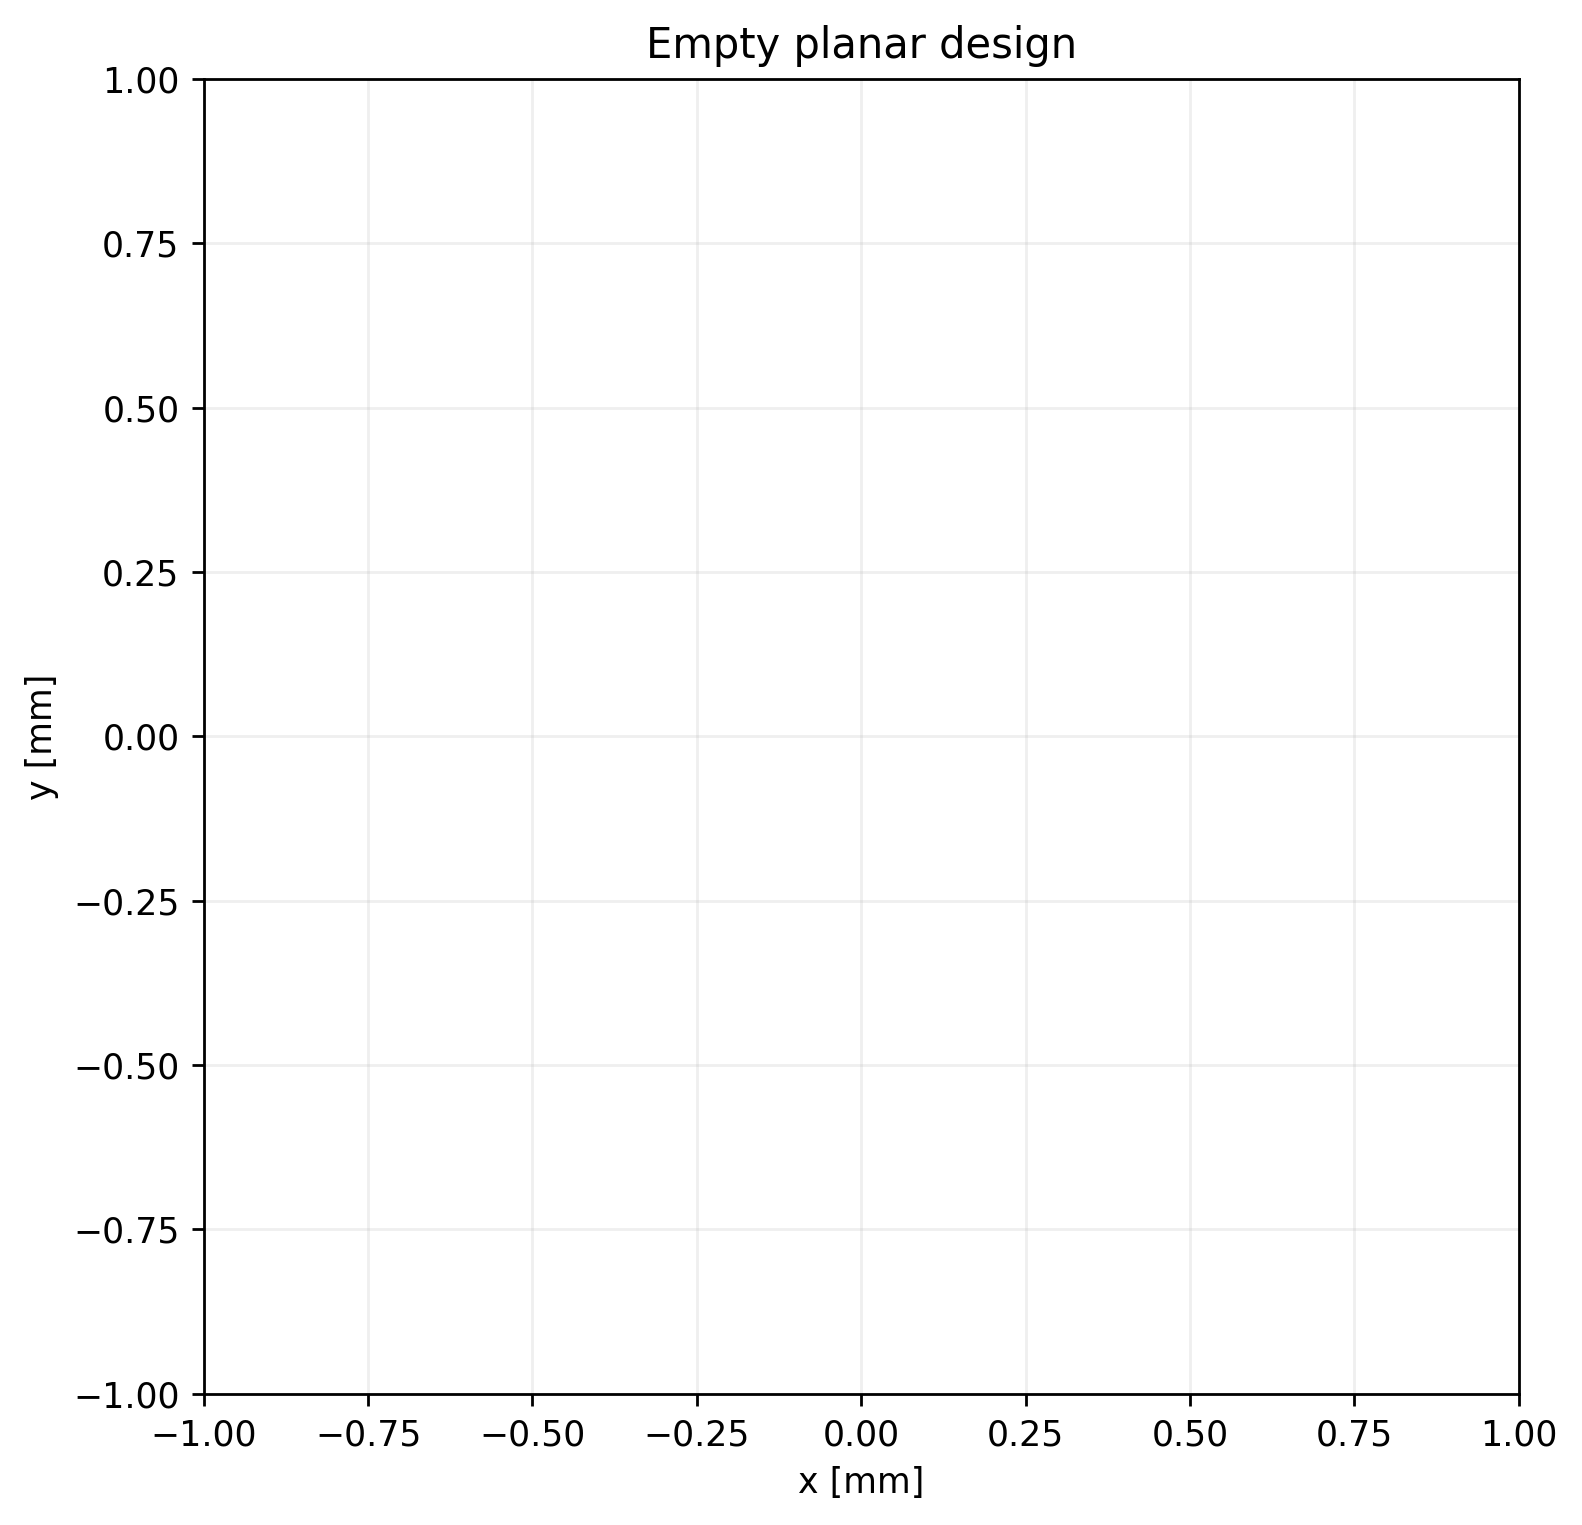

Design units: mm
Overwrite enabled: True
Quantum Metal renderers enabled: False

Initial qgeometry summary


,table,rows,columns,component_count
0,path,0,"component, name, geometry, layer, subtract, he...",0
1,poly,0,"component, name, geometry, layer, subtract, he...",0
2,junction,0,"component, name, geometry, layer, subtract, he...",0


In [ ]:
"""Create the first headless planar Quantum Metal design."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

DESIGN_OVERWRITE_ENABLED = True
ENABLE_RENDERERS = False
CHIP_SIZE_X = "6.0mm"
CHIP_SIZE_Y = "4.0mm"
EMPTY_DESIGN_TITLE = "Empty planar design"

print_heading("My first Quantum Design")

design = new_planar_design(
    overwrite_enabled=DESIGN_OVERWRITE_ENABLED,
    enable_renderers=ENABLE_RENDERERS,
)

design.chips.main.size.size_x = CHIP_SIZE_X
design.chips.main.size.size_y = CHIP_SIZE_Y
rebuild_design(design)

fig, _ = plot_design(
    design,
    title=EMPTY_DESIGN_TITLE,
    show_pins=False,
)
show_figure(fig)

print(f"Design units: {design.get_units()}")
print(f"Overwrite enabled: {design.overwrite_enabled}")
print(f"Quantum Metal renderers enabled: {ENABLE_RENDERERS}")
show_table(qgeometry_summary(design), "Initial qgeometry summary")


## Cell 04: qm_quick_start_cell_04_single_transmon.py



My first Quantum Component


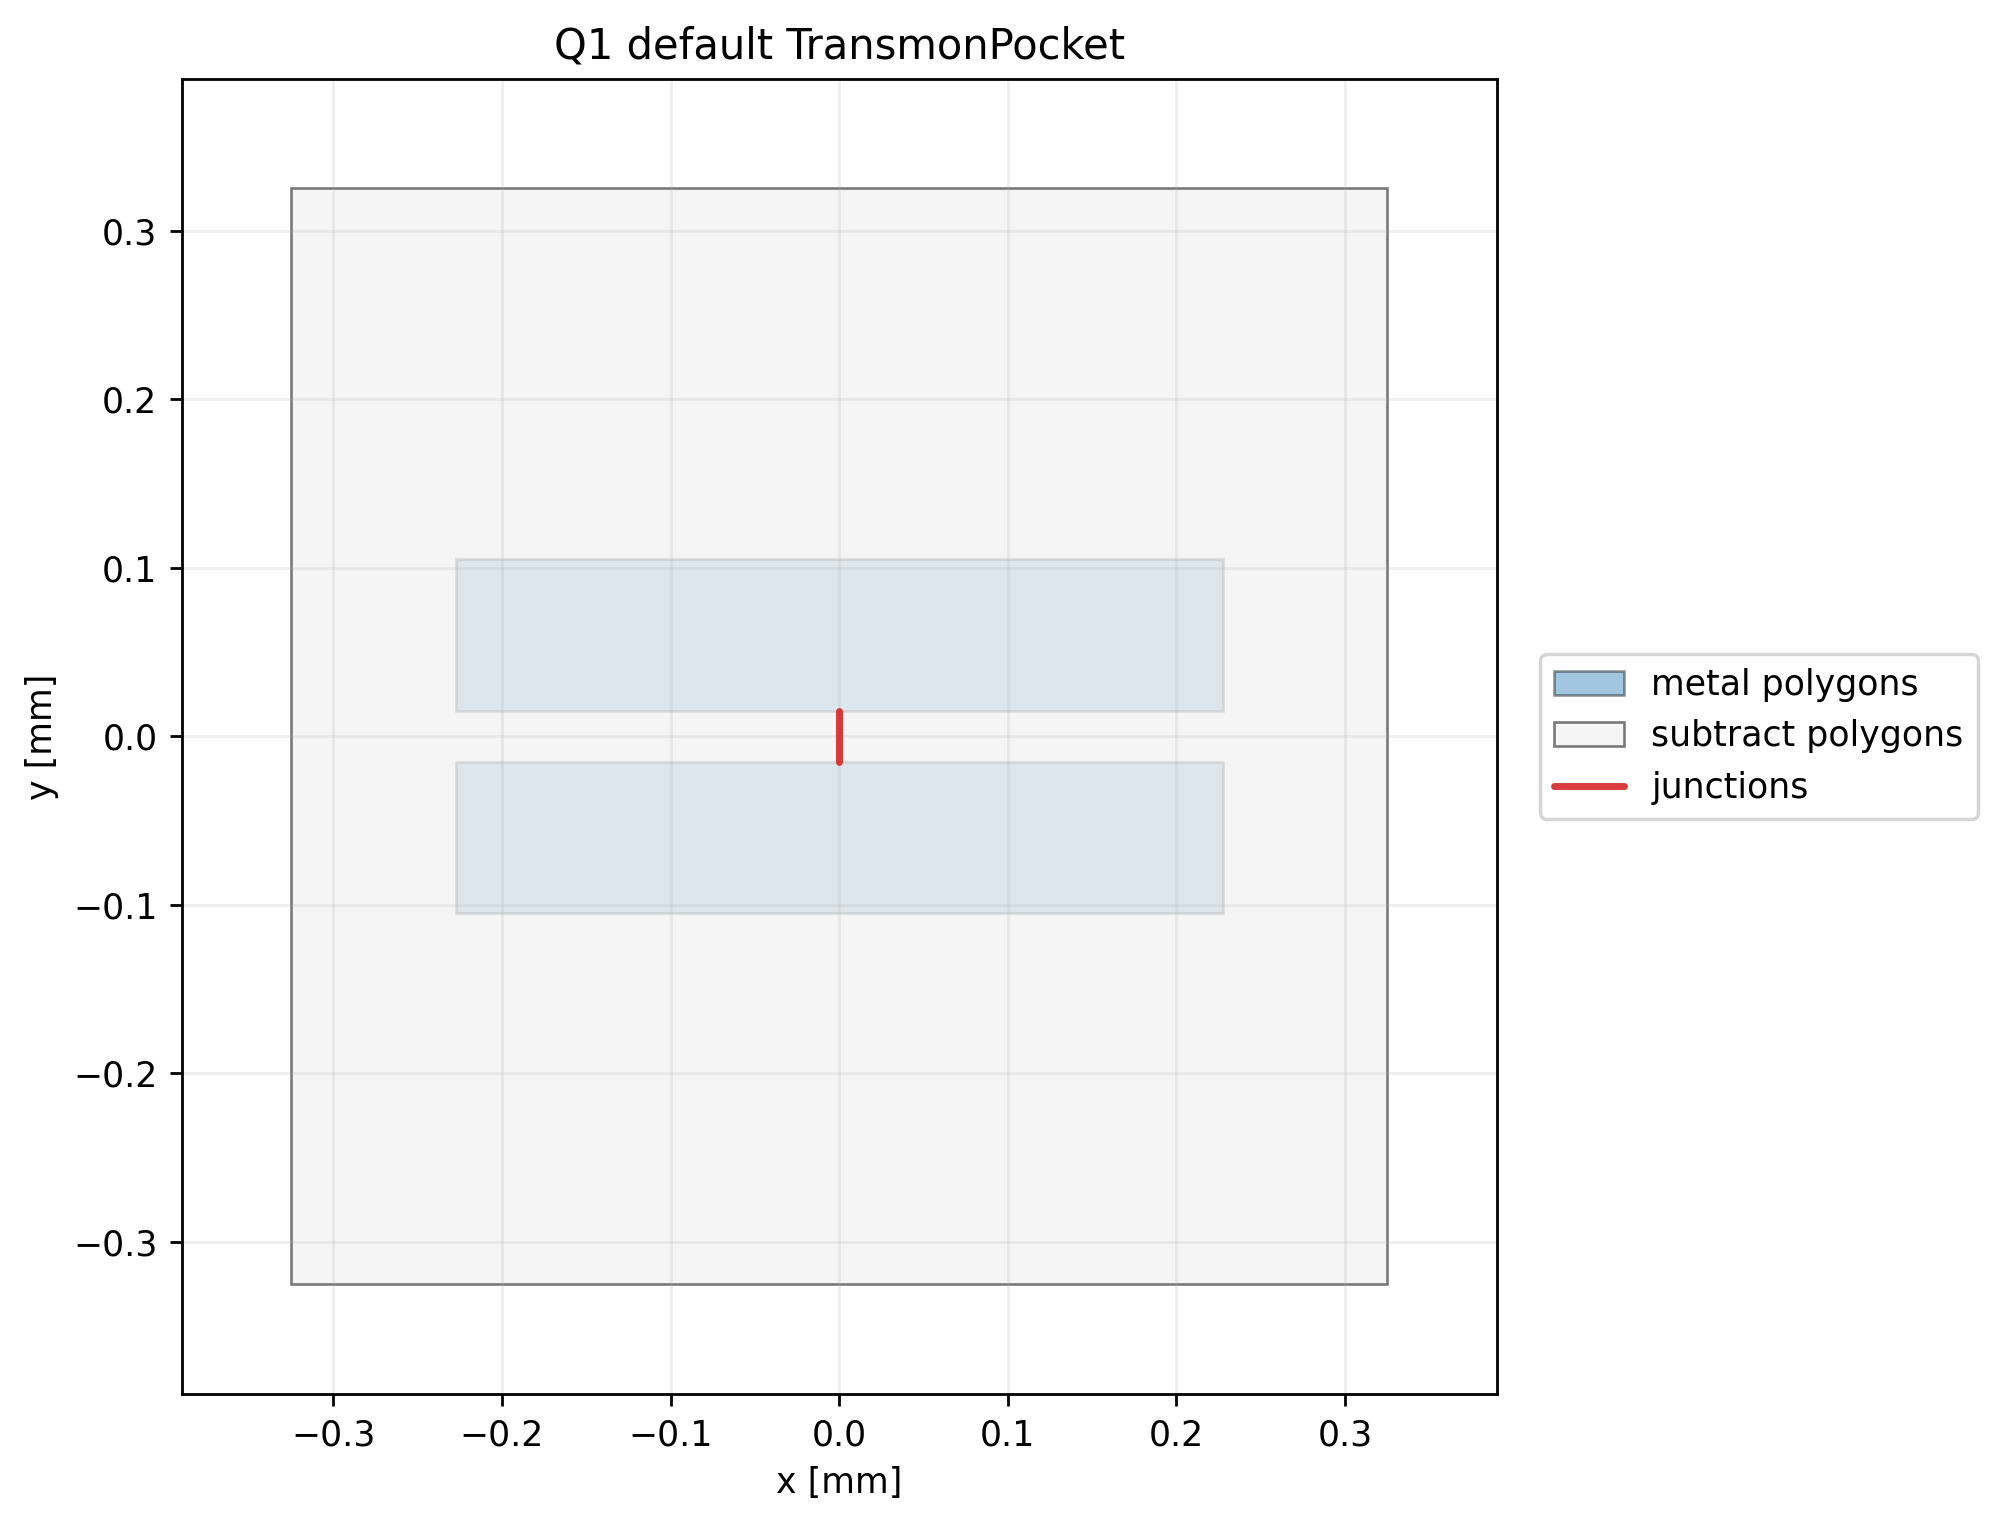


Q1 initial bounds


,component,id,min_x,min_y,max_x,max_y,width,height
0,Q1,1,-0.325,-0.325,0.325,0.325,0.65,0.65



QGeometry after creating Q1


,table,rows,columns,component_count
0,path,0,"component, name, geometry, layer, subtract, he...",0
1,poly,3,"component, name, geometry, layer, subtract, he...",1
2,junction,1,"component, name, geometry, layer, subtract, he...",1


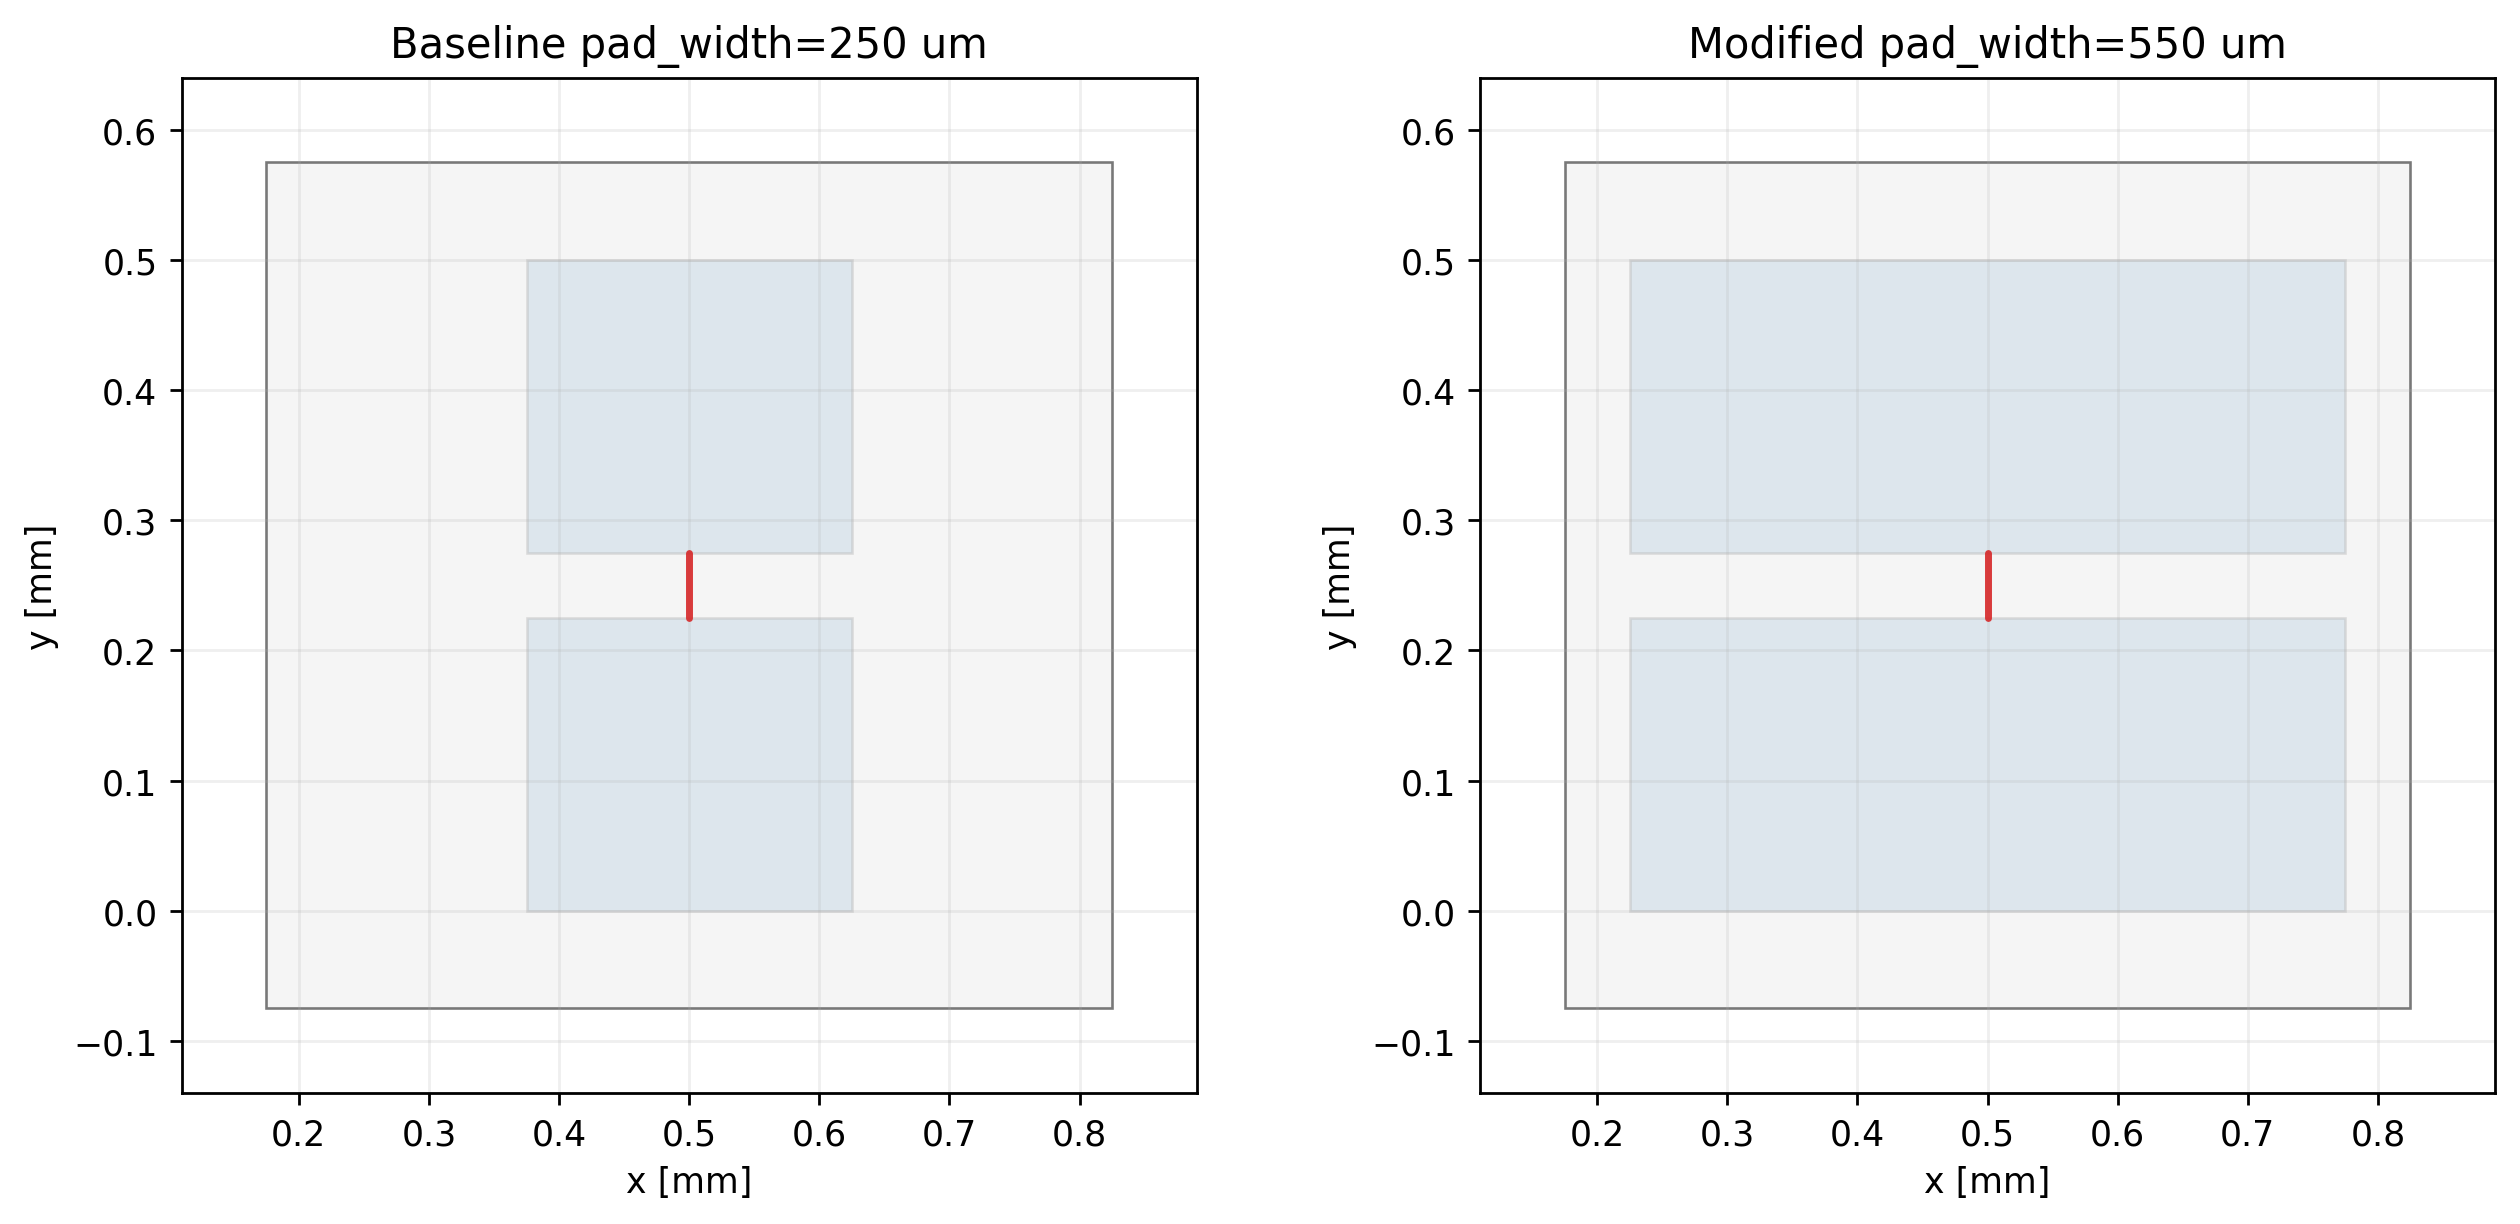

Restored pad_width to 250 um

Q1 restored bounds


,component,id,min_x,min_y,max_x,max_y,width,height
0,Q1,1,0.175,-0.075,0.825,0.575,0.65,0.65


In [ ]:
"""Create, modify, and compare one TransmonPocket component."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

QUBIT_NAME = "Q1"
INITIAL_QUBIT_TITLE = "Q1 default TransmonPocket"
UPDATED_POS_X = "0.5 mm"
UPDATED_POS_Y = "0.25 mm"
UPDATED_PAD_HEIGHT = "225 um"
UPDATED_PAD_WIDTH = "250 um"
UPDATED_PAD_GAP = "50 um"
COMPARISON_PAD_WIDTH = "550 um"

print_heading("My first Quantum Component")

design.overwrite_enabled = True

q1 = TransmonPocket(design, QUBIT_NAME)
rebuild_design(design)

fig, _ = plot_design(
    design,
    components=[QUBIT_NAME],
    title=INITIAL_QUBIT_TITLE,
)
show_figure(fig)

show_table(component_bounds_table(design), "Q1 initial bounds")
show_table(qgeometry_summary(design), "QGeometry after creating Q1")

q1.options.pos_x = UPDATED_POS_X
q1.options.pos_y = UPDATED_POS_Y
q1.options.pad_height = UPDATED_PAD_HEIGHT
q1.options.pad_width = UPDATED_PAD_WIDTH
q1.options.pad_gap = UPDATED_PAD_GAP
rebuild_design(design)

baseline_pad_width = q1.options.pad_width

fig, axes = plt.subplots(1, 2, figsize=COMPARISON_FIGURE_SIZE)
plot_design(
    design,
    components=[QUBIT_NAME],
    title=f"Baseline pad_width={baseline_pad_width}",
    ax=axes[0],
    show_legend=False,
)

q1.options.pad_width = COMPARISON_PAD_WIDTH
rebuild_design(design)

plot_design(
    design,
    components=[QUBIT_NAME],
    title=f"Modified pad_width={COMPARISON_PAD_WIDTH}",
    ax=axes[1],
    show_legend=False,
)

plt.tight_layout()
show_figure(fig)

q1.options.pad_width = baseline_pad_width
rebuild_design(design)

print(f"Restored pad_width to {q1.options.pad_width}")
show_table(component_bounds_table(design), "Q1 restored bounds")


## Cell 05: qm_quick_start_cell_05_units_qgeometry_qpins.py



Options, units, QGeometry, and QPins

TransmonPocket template options


,key,value,type
0,pos_x,0.0um,str
1,pos_y,0.0um,str
2,orientation,0.0,str
3,chip,main,str
4,layer,1,str
5,_default_connection_pads.pad_gap,15um,str
6,_default_connection_pads.pad_width,125um,str
7,_default_connection_pads.pad_height,30um,str
8,_default_connection_pads.pad_cpw_shift,5um,str
9,_default_connection_pads.pad_cpw_extent,25um,str



Parsing strings into design units
Design default units for length: mm
Example 250 micron parsed to design units: 0.25 mm
Example parsed dictionary: {'key_in_cm': 12.0, 'key_in_microns': 0.05}
Example parsed list: [1000.0, 1, 0.001, 1.0000000000000002e-06]
2 * 2um = 0.004
2um + 5um = 0.007


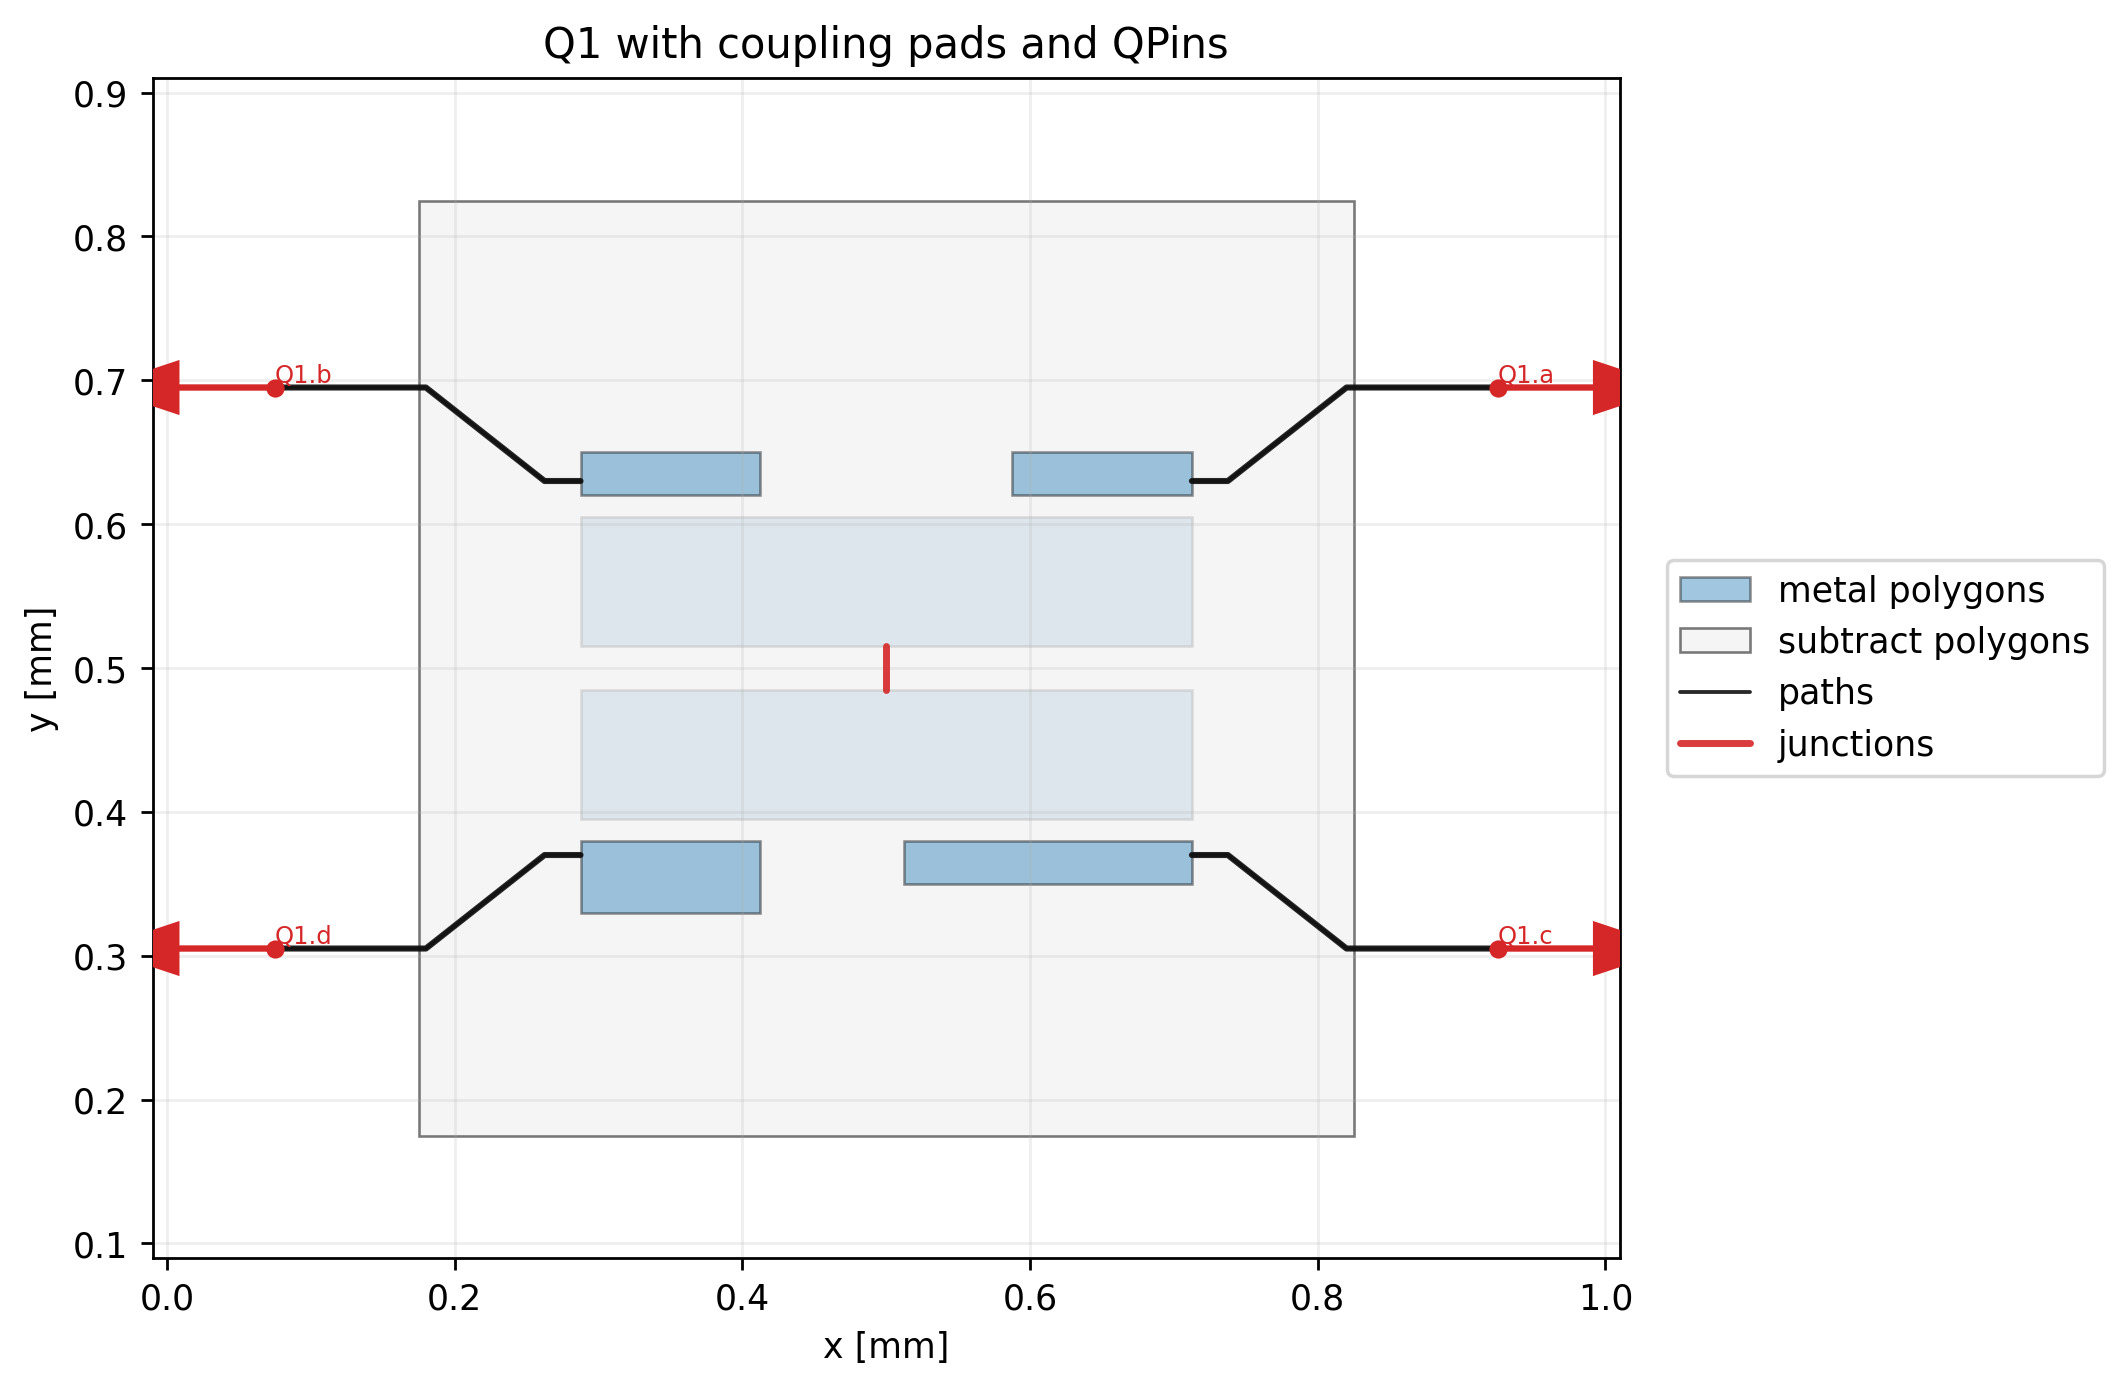

Available pins: ['a', 'b', 'c', 'd']
Pin a through attribute access:


{'points': [array([0.925, 0.7  ]), array([0.925, 0.69 ])],
 'middle': array([0.925, 0.695]),
 'normal': array([1., 0.]),
 'tangent': array([0., 1.]),
 'width': 0.01,
 'gap': 0.006,
 'chip': 'main',
 'parent_name': 2,
 'net_id': 0,
 'length': 0}

Pin a through dictionary access:


{'points': [array([0.925, 0.7  ]), array([0.925, 0.69 ])],
 'middle': array([0.925, 0.695]),
 'normal': array([1., 0.]),
 'tangent': array([0., 1.]),
 'width': 0.01,
 'gap': 0.006,
 'chip': 'main',
 'parent_name': 2,
 'net_id': 0,
 'length': 0}


Single-qubit bounds


...

,component,name,geometry,layer,subtract,helper,chip,fillet
0,2,pad_top,"POLYGON ((0.2875 0.515, 0.7125 0.515, 0.7125 0...",1,False,False,main,NaN
1,2,pad_bot,"POLYGON ((0.2875 0.395, 0.7125 0.395, 0.7125 0...",1,False,False,main,NaN
2,2,rect_pk,"POLYGON ((0.175 0.175, 0.825 0.175, 0.825 0.82...",1,True,False,main,NaN
3,2,a_connector_pad,"POLYGON ((0.5875 0.62, 0.7125 0.62, 0.7125 0.6...",1,False,False,main,NaN
4,2,b_connector_pad,"POLYGON ((0.4125 0.62, 0.2875 0.62, 0.2875 0.6...",1,False,False,main,NaN
5,2,c_connector_pad,"POLYGON ((0.5125 0.38, 0.7125 0.38, 0.7125 0.3...",1,False,False,main,NaN
6,2,d_connector_pad,"POLYGON ((0.4125 0.38, 0.2875 0.38, 0.2875 0.3...",1,False,False,main,NaN



Q1 qgeometry table: path


,component,name,geometry,layer,subtract,helper,chip,width,fillet
0,2,a_wire,"LINESTRING (0.7125 0.63, 0.7375 0.63, 0.82 0.6...",1,False,False,main,0.010,NaN
1,2,a_wire_sub,"LINESTRING (0.7125 0.63, 0.7375 0.63, 0.82 0.6...",1,True,False,main,0.022,NaN
2,2,b_wire,"LINESTRING (0.2875 0.63, 0.2625 0.63, 0.18 0.6...",1,False,False,main,0.010,NaN
3,2,b_wire_sub,"LINESTRING (0.2875 0.63, 0.2625 0.63, 0.18 0.6...",1,True,False,main,0.022,NaN
4,2,c_wire,"LINESTRING (0.7125 0.37, 0.7375 0.37, 0.82 0.3...",1,False,False,main,0.010,NaN
5,2,c_wire_sub,"LINESTRING (0.7125 0.37, 0.7375 0.37, 0.82 0.3...",1,True,False,main,0.022,NaN
6,2,d_wire,"LINESTRING (0.2875 0.37, 0.2625 0.37, 0.18 0.3...",1,False,False,main,0.010,NaN
7,2,d_wire_sub,"LINESTRING (0.2875 0.37, 0.2625 0.37, 0.18 0.3...",1,True,False,main,0.022,NaN



Q1 qgeometry table: junction


,component,name,geometry,layer,subtract,helper,chip,width
0,2,rect_jj,"LINESTRING (0.5 0.485, 0.5 0.515)",1,False,False,main,0.02


In [ ]:
"""Inspect default options, unit parsing, qgeometry tables, and QPins."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

CLEAR_EXISTING_COMPONENTS = True
QUBIT_NAME = "Q1"
SHOW_FULL_TEMPLATE_OPTIONS = True
TABLE_NAMES = ("poly", "path", "junction")

SINGLE_QUBIT_OPTIONS = dict(
    pad_width="425 um",
    pocket_height="650um",
    connection_pads=dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

print_heading("Options, units, QGeometry, and QPins")

if SHOW_FULL_TEMPLATE_OPTIONS:
    show_table(
        TransmonPocket.get_template_options(design),
        "TransmonPocket template options",
    )

print_note("Parsing strings into design units")
print("Design default units for length:", design.get_units())
print(
    "Example 250 micron parsed to design units:",
    design.parse_value("250 um"),
    design.get_units(),
)
print("Example parsed dictionary:", design.parse_value(
    {"key_in_cm": "1.2 cm", "key_in_microns": "50 um"}
))
print("Example parsed list:", design.parse_value(["1m", "1mm", "1um", "1 nm"]))
print("2 * 2um =", design.parse_value("2 * 2um"))
print("2um + 5um =", design.parse_value("2um + 5um"))

if CLEAR_EXISTING_COMPONENTS:
    design.delete_all_components()

q1 = TransmonPocket(
    design,
    QUBIT_NAME,
    options=dict(pos_x="+0.5mm", pos_y="+0.5mm", **SINGLE_QUBIT_OPTIONS),
)
rebuild_design(design)

fig, _ = plot_design(
    design,
    components=[QUBIT_NAME],
    title="Q1 with coupling pads and QPins",
    show_pins=True,
)
show_figure(fig)

print("Available pins:", list(q1.pins.keys()))
print("Pin a through attribute access:")
display(q1.pins.a)
print("Pin a through dictionary access:")
display(q1.pins["a"])

show_table(component_bounds_table(design), "Single-qubit bounds")
show_table(qgeometry_summary(design), "Single-qubit qgeometry summary")

for table_name in TABLE_NAMES:
    try:
        table = q1.qgeometry_table(table_name)
    except Exception as error:  # noqa: BLE001
        print(f"{table_name} table unavailable: {error}")
        continue

    show_table(table, f"Q1 qgeometry table: {table_name}")


## Cell 06: qm_quick_start_cell_06_four_qubit_chip.py



My first quantum chip


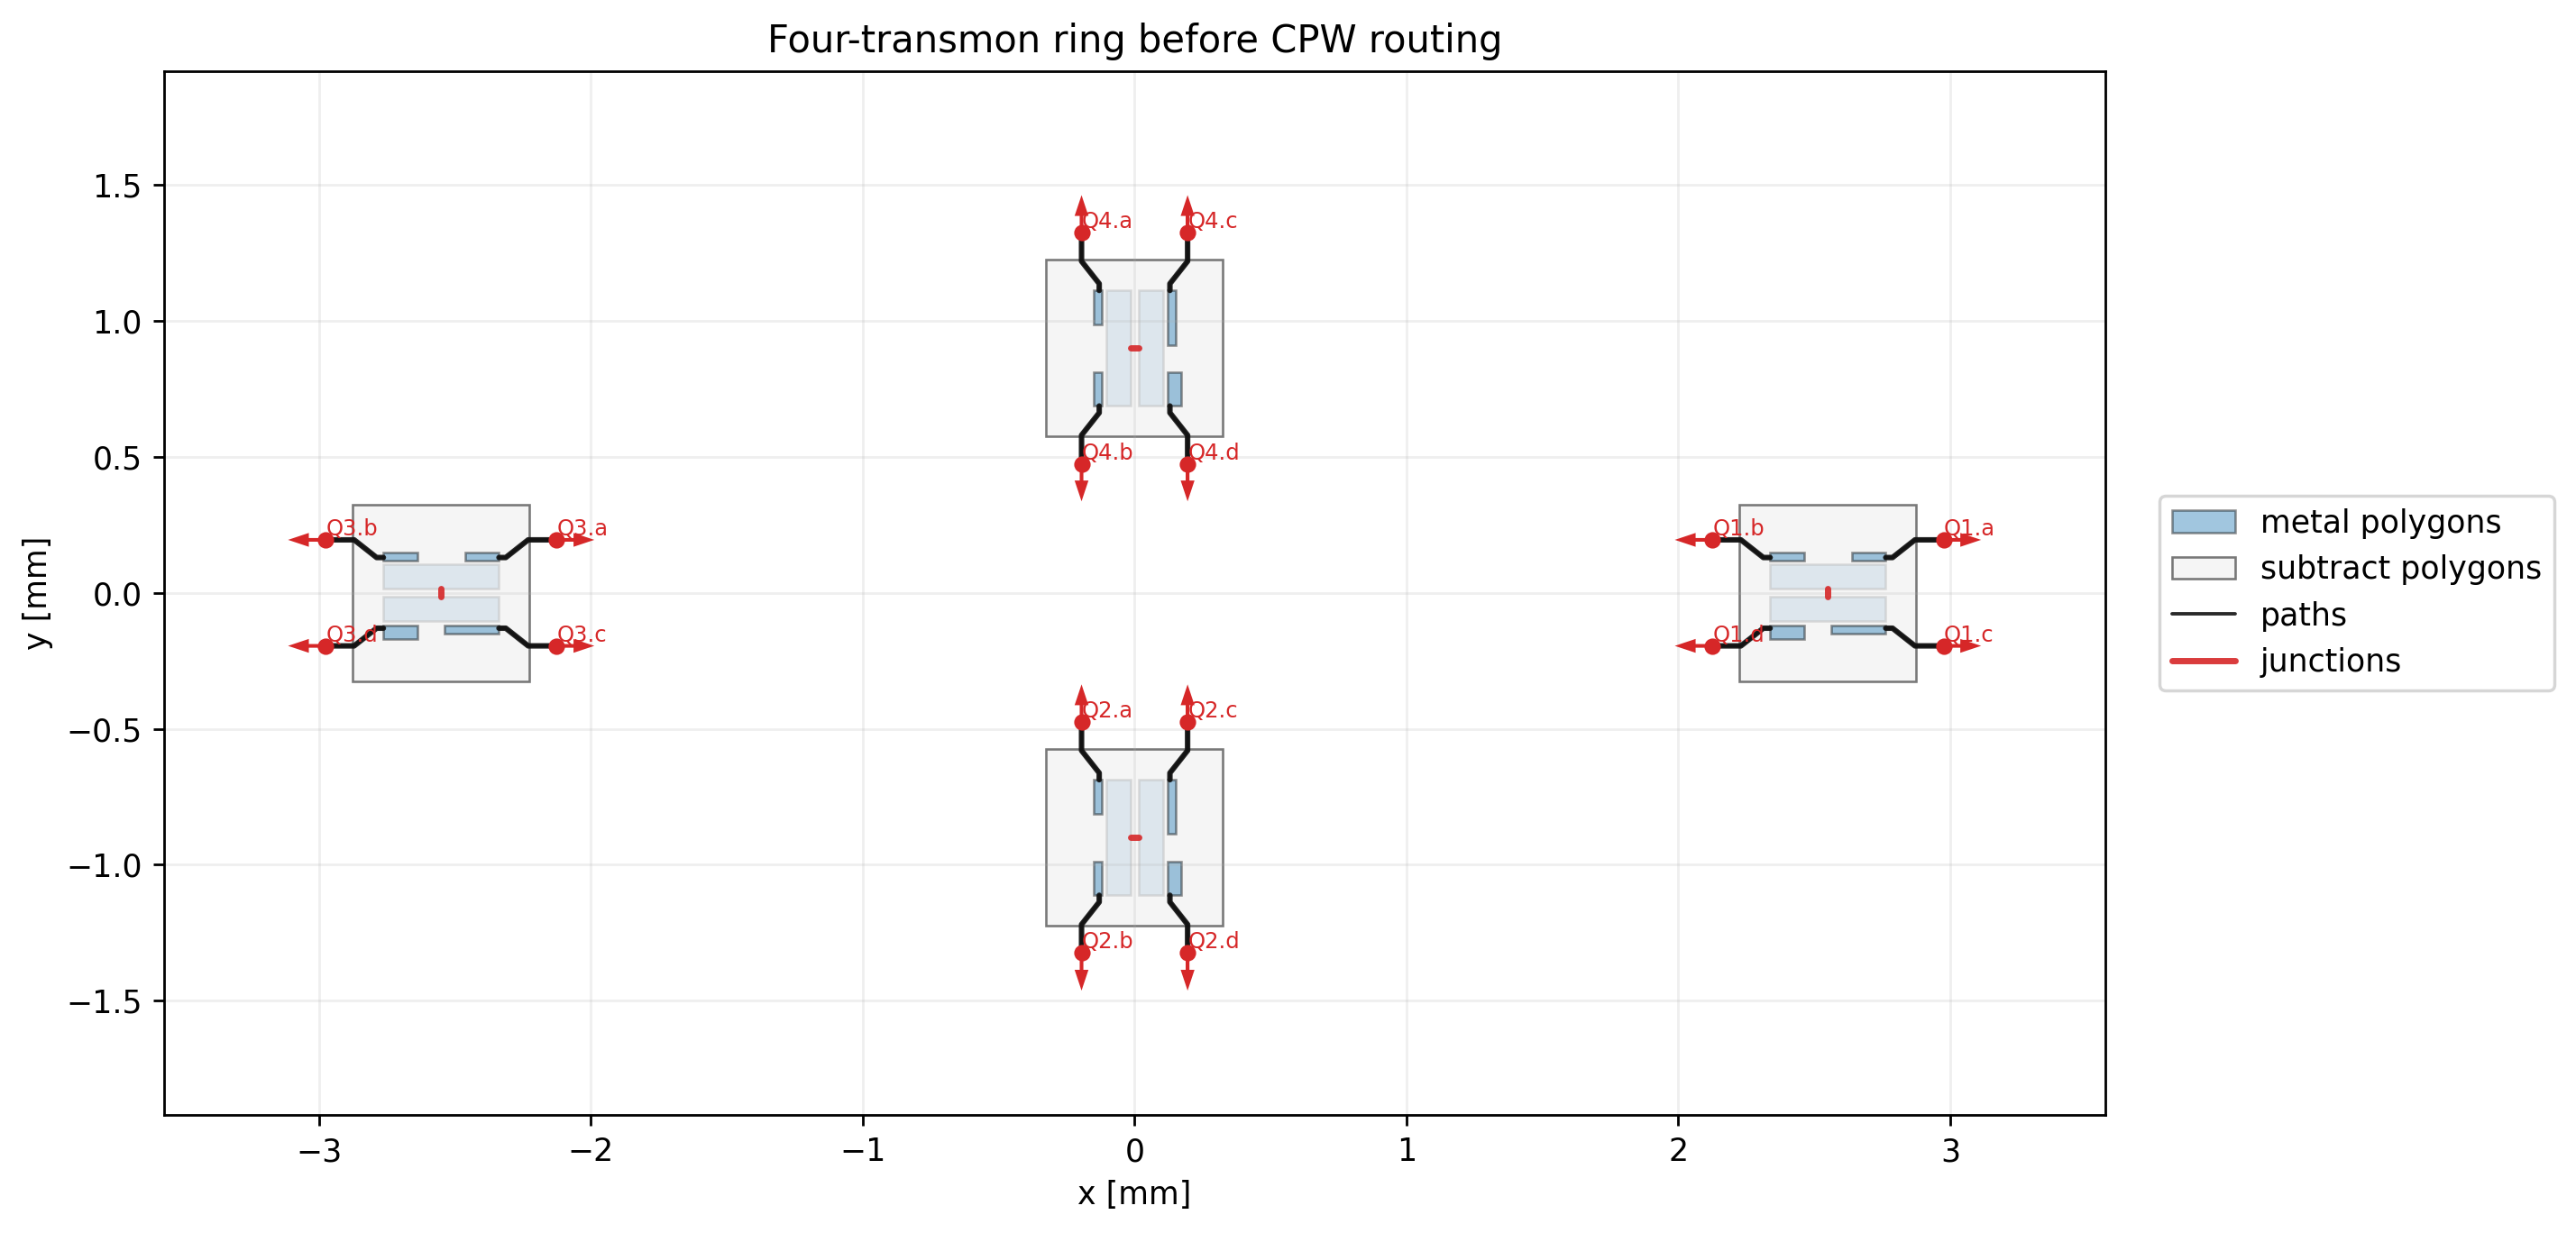

Components: ['Q1', 'Q2', 'Q3', 'Q4']

Four-qubit component bounds


,component,id,min_x,min_y,max_x,max_y,width,height
0,Q1,3,2.125,-0.325,2.975,0.325,0.85,0.65
1,Q2,4,-0.325,-1.325,0.325,-0.475,0.65,0.85
2,Q3,5,-2.975,-0.325,-2.125,0.325,0.85,0.65
3,Q4,6,-0.325,0.475,0.325,1.325,0.65,0.85



Four-qubit qgeometry summary


,table,rows,columns,component_count
0,path,32,"component, name, geometry, layer, subtract, he...",4
1,poly,28,"component, name, geometry, layer, subtract, he...",4
2,junction,4,"component, name, geometry, layer, subtract, he...",4


In [ ]:
"""Create a coherent four-transmon chip for the routed final layout."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

CLEAR_EXISTING_COMPONENTS = True
SHOW_PINS = True

FOUR_QUBIT_OPTIONS = dict(
    pad_width="425 um",
    pocket_height="650um",
    gds_cell_name="FakeJunction_01",
    connection_pads=dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

FOUR_QUBIT_PLACEMENT = {
    "Q1": dict(pos_x="+2.55mm", pos_y="+0.0mm", orientation="0"),
    "Q2": dict(pos_x="+0.0mm", pos_y="-0.9mm", orientation="90"),
    "Q3": dict(pos_x="-2.55mm", pos_y="+0.0mm", orientation="0"),
    "Q4": dict(pos_x="+0.0mm", pos_y="+0.9mm", orientation="90"),
}

print_heading("My first quantum chip")

if CLEAR_EXISTING_COMPONENTS:
    design.delete_all_components()

design.overwrite_enabled = True

qubits = {}
for qubit_name, placement in FOUR_QUBIT_PLACEMENT.items():
    qubits[qubit_name] = TransmonPocket(
        design,
        qubit_name,
        options=dict(**placement, **FOUR_QUBIT_OPTIONS),
    )

rebuild_design(design)

fig, _ = plot_design(
    design,
    components=list(FOUR_QUBIT_PLACEMENT),
    title="Four-transmon ring before CPW routing",
    show_pins=SHOW_PINS,
    figure_size=WIDE_FIGURE_SIZE,
)
show_figure(fig)

print("Components:", list(design.components.keys()))
show_table(component_bounds_table(design), "Four-qubit component bounds")
show_table(qgeometry_summary(design), "Four-qubit qgeometry summary")


## Cell 07: qm_quick_start_cell_07_connect_cpws_variables.py



Connecting QPins with coplanar waveguides

GDS path smoothing settings


,use_phidl_smoothing,radius_design_units,corner_style,min_point_spacing
0,True,0.09,euler,0.000001


/content/qiskit-metal/src/qiskit_metal/qgeometries/qgeometries_handler.py:539: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.tables[kind] = pd.concat(


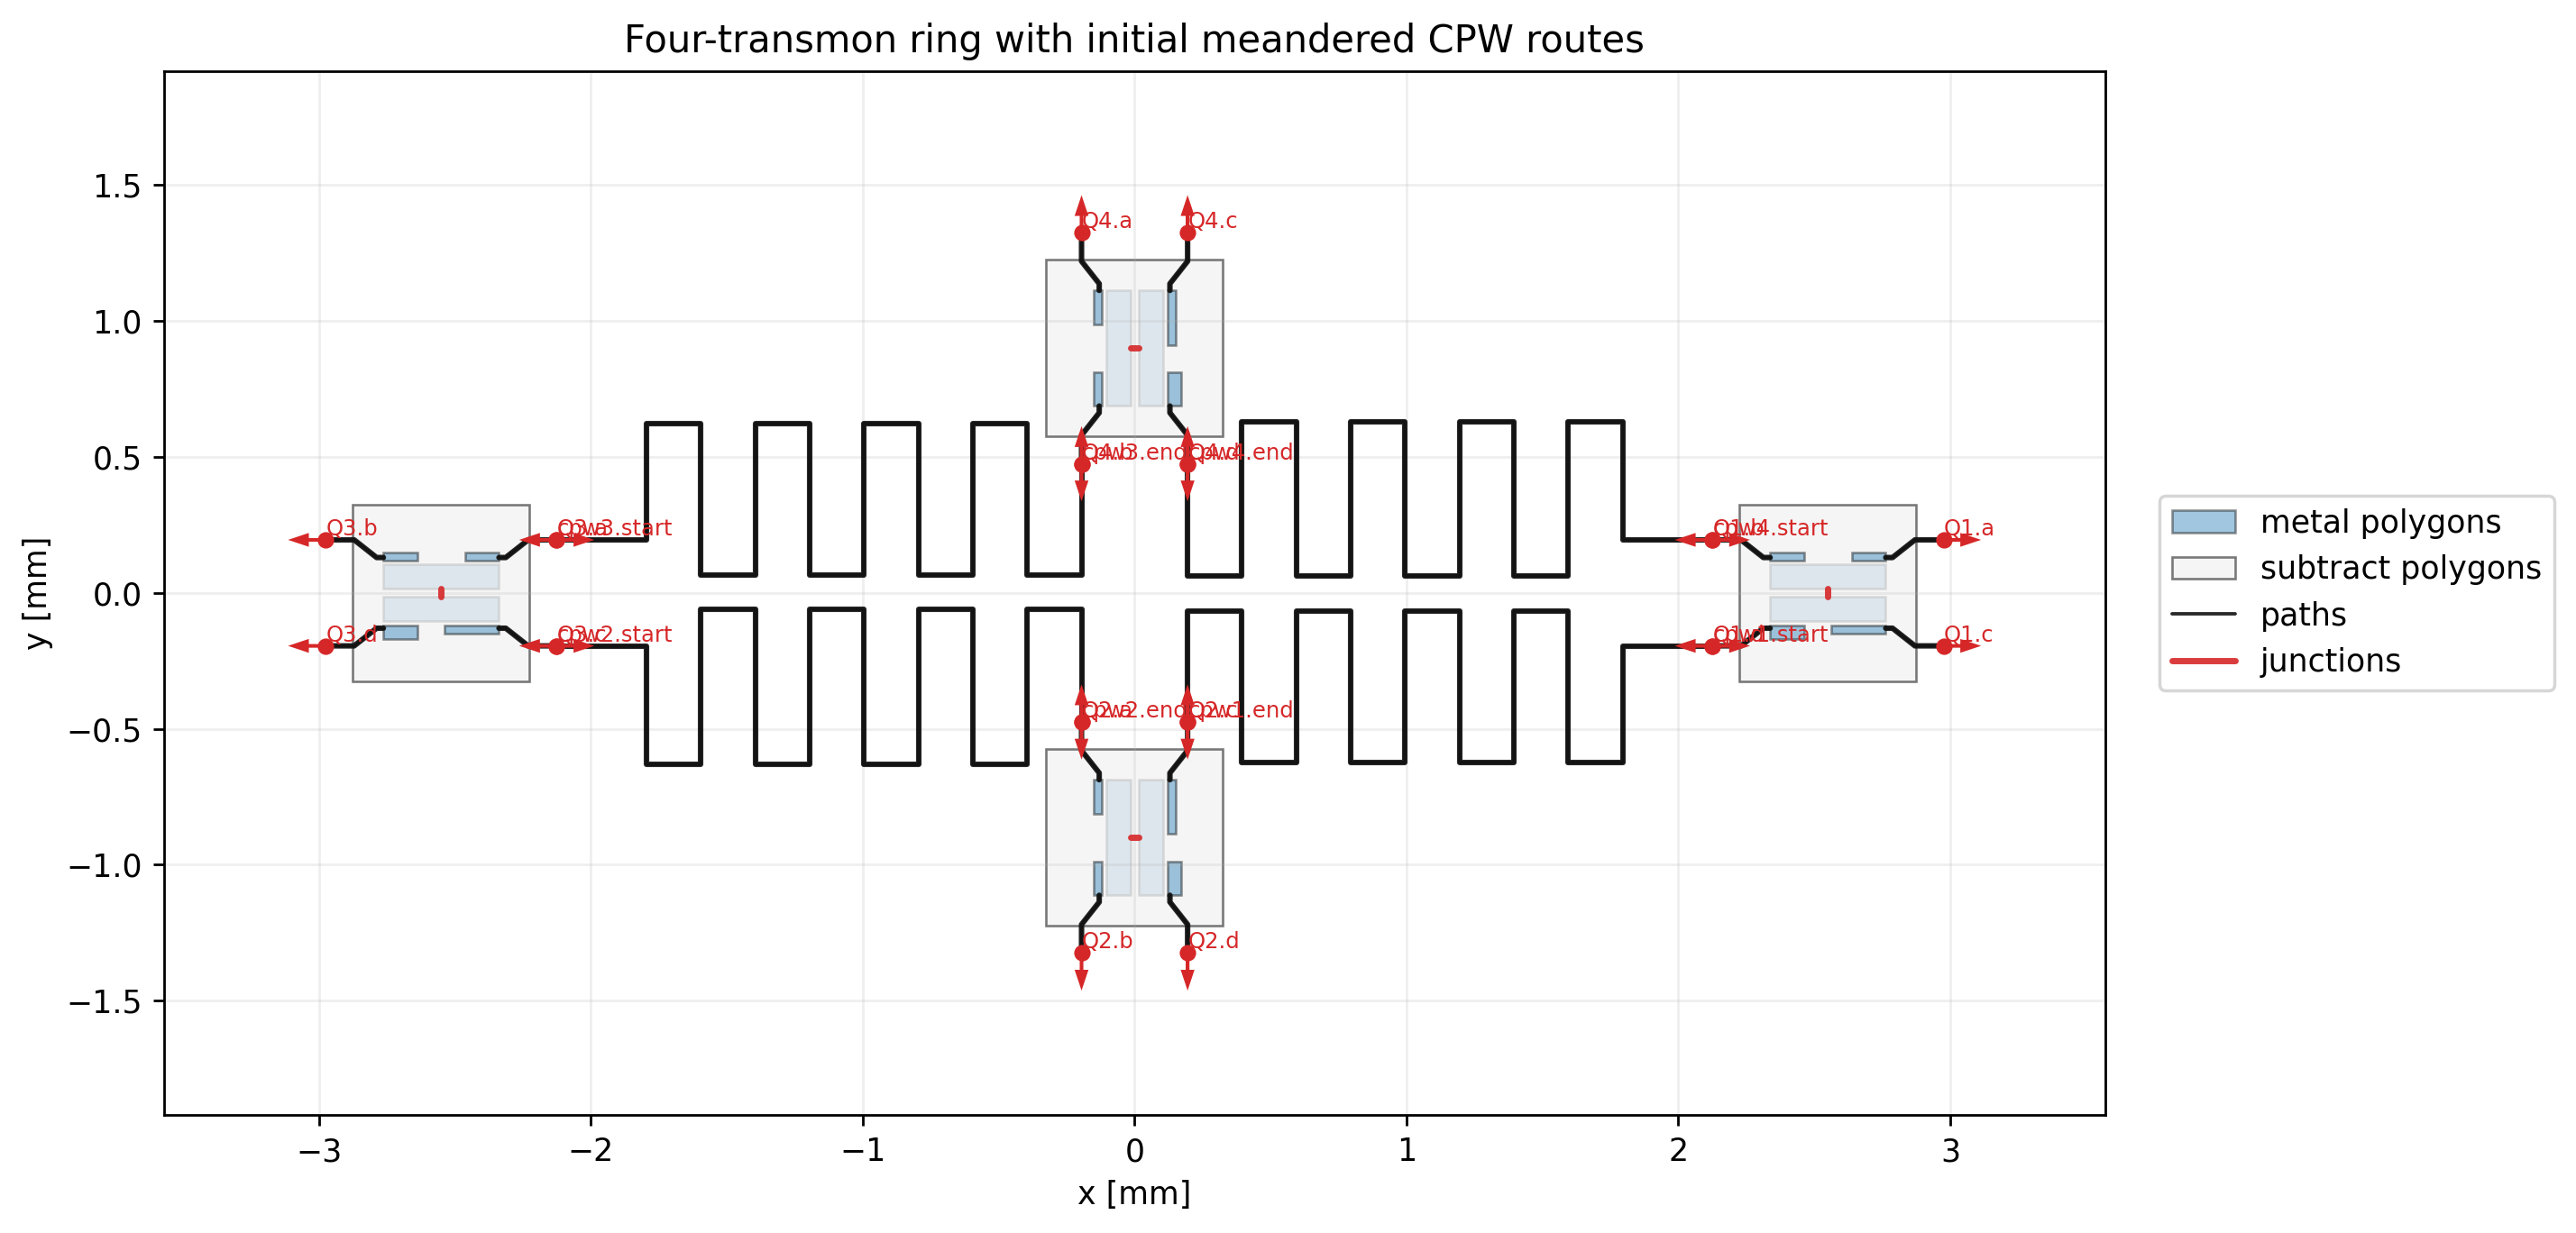

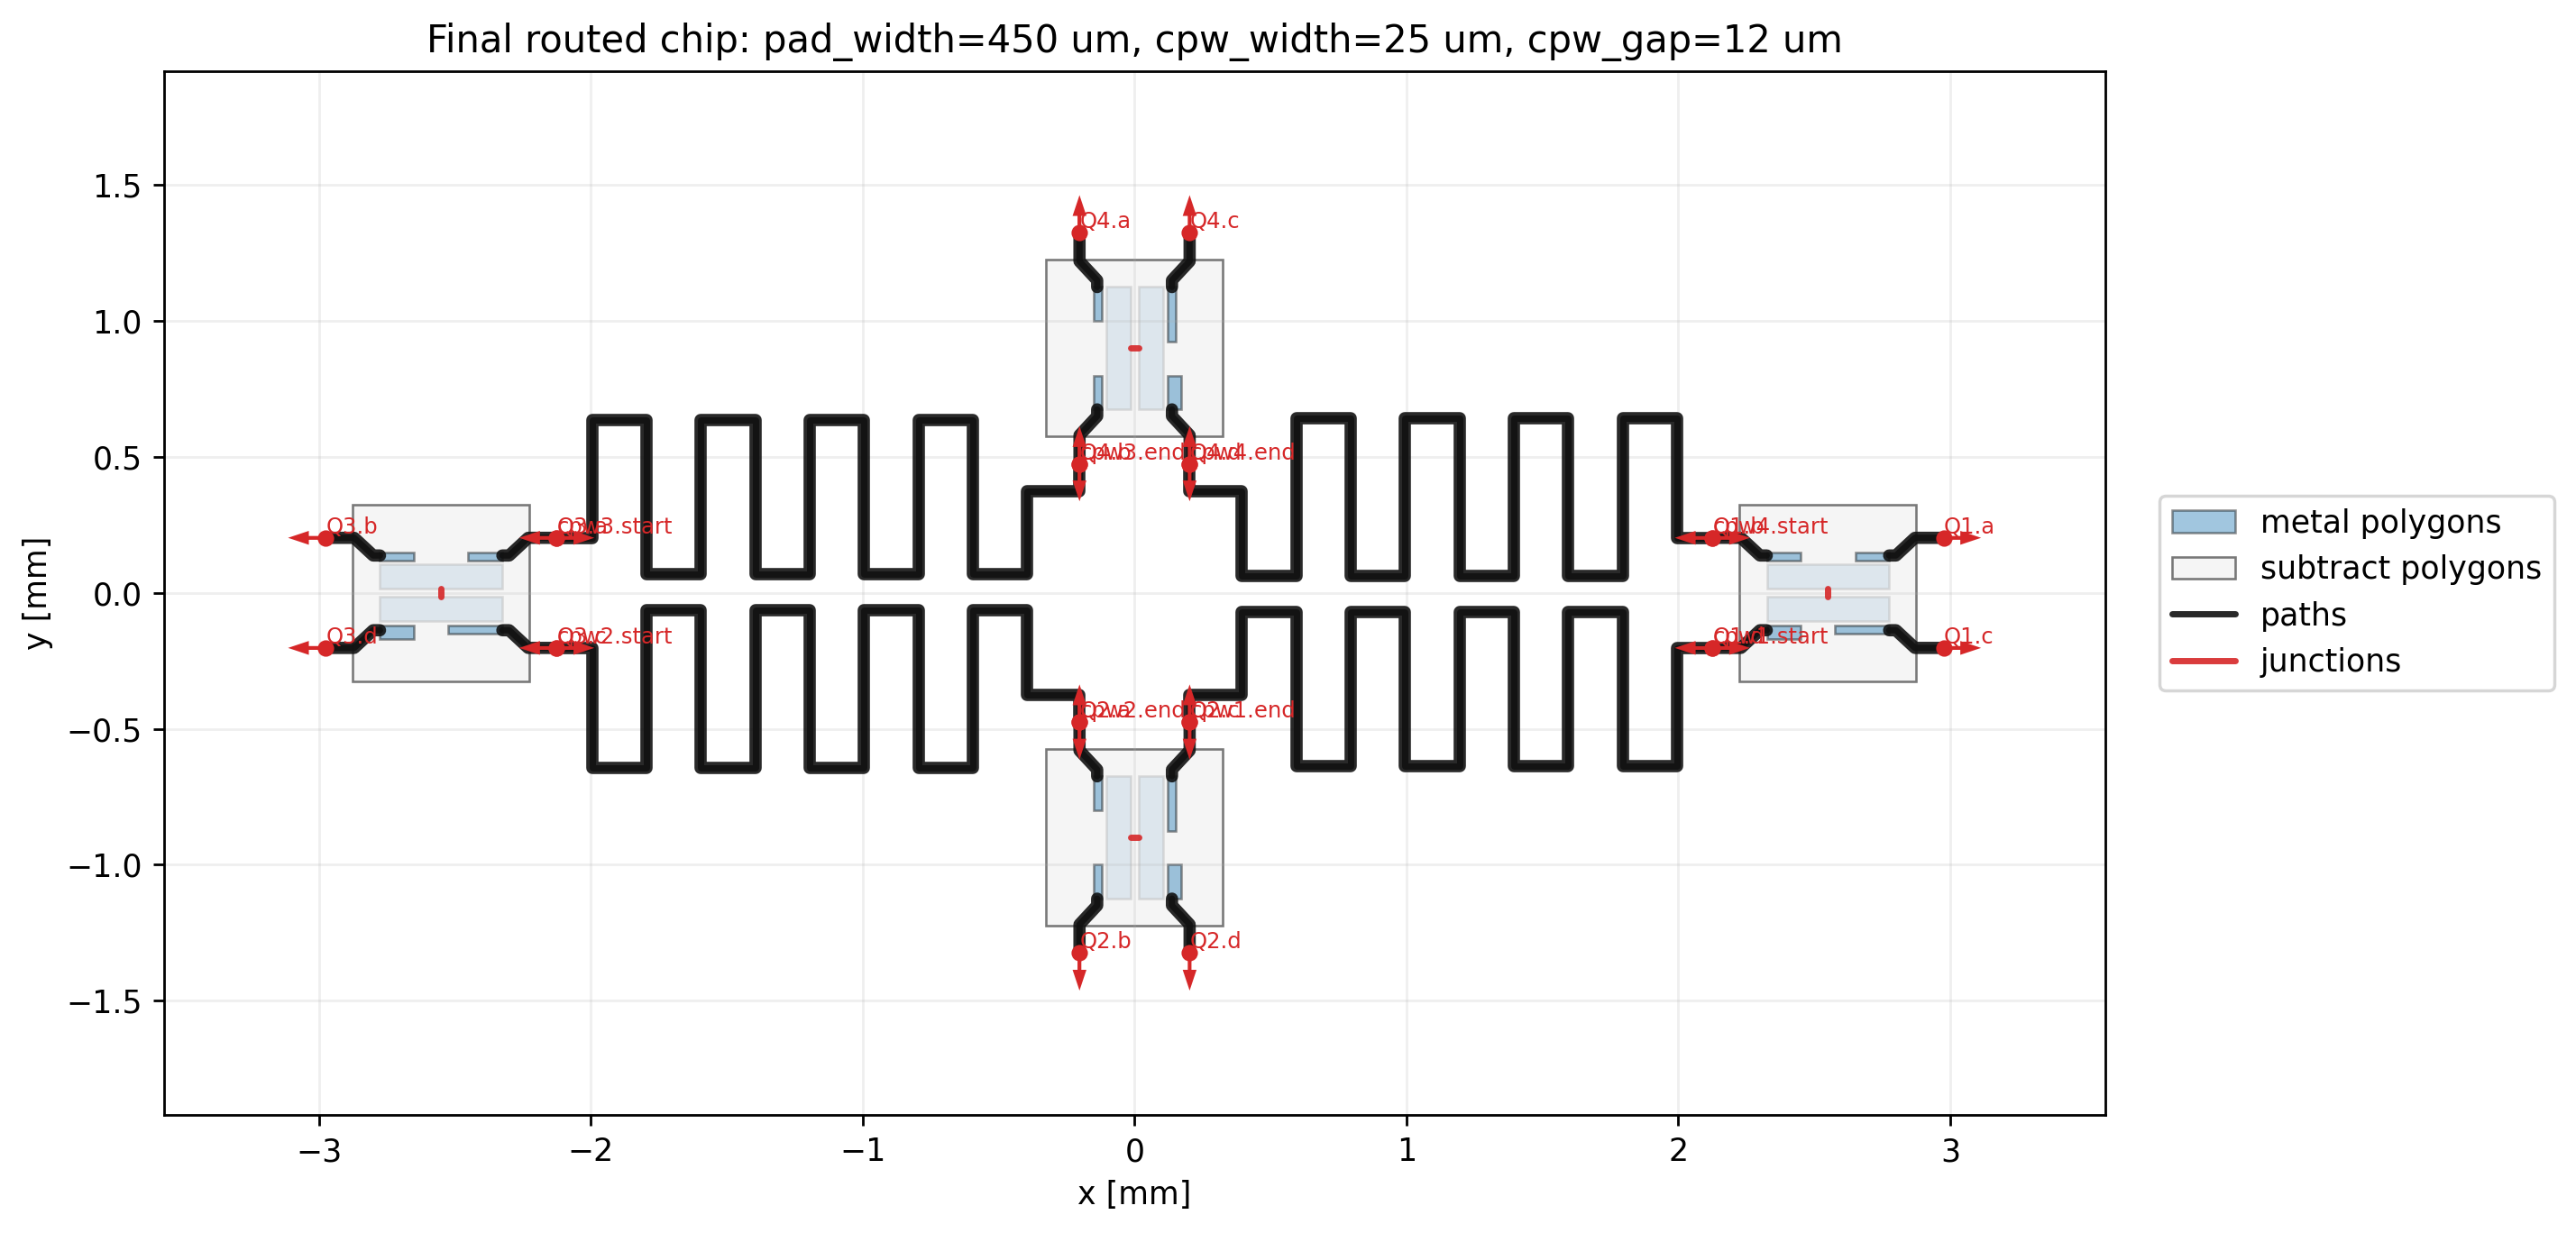

Components after routing: ['Q1', 'Q2', 'Q3', 'Q4', 'cpw1', 'cpw2', 'cpw3', 'cpw4']

Final routed component bounds


,component,id,min_x,min_y,max_x,max_y,width,height
0,Q1,3,2.1250,-0.325000,2.9750,0.325000,0.8500,0.650000
1,Q2,4,-0.3250,-1.325000,0.3250,-0.475000,0.6500,0.850000
2,Q3,5,-2.9750,-0.325000,-2.1250,0.325000,0.8500,0.650000
3,Q4,6,-0.3250,0.475000,0.3250,1.325000,0.6500,0.850000
4,cpw1,7,0.2025,-0.636184,2.1250,-0.068816,1.9225,0.567367
5,cpw2,8,-2.1250,-0.642434,-0.2025,-0.062566,1.9225,0.579867
6,cpw3,9,-2.1250,0.068816,-0.2025,0.636184,1.9225,0.567367
7,cpw4,10,0.2025,0.062566,2.1250,0.642434,1.9225,0.579867



Final routed qgeometry summary


,table,rows,columns,component_count
0,path,40,"component, name, geometry, layer, subtract, he...",8
1,poly,28,"component, name, geometry, layer, subtract, he...",4
2,junction,4,"component, name, geometry, layer, subtract, he...",4



Example routed CPW options: cpw2


,key,value,type
0,chip,main,str
1,layer,1,str
2,pin_inputs.start_pin.component,Q3,str
3,pin_inputs.start_pin.pin,c,str
4,pin_inputs.end_pin.component,Q2,str
5,pin_inputs.end_pin.pin,a,str
6,fillet,90um,str
7,lead.start_straight,0.13mm,str
8,lead.end_straight,100um,str
9,lead.start_jogged_extension,,str



Active PHIDL smoothing for final GDS


,use_phidl_smoothing,radius_design_units,corner_style,min_point_spacing
0,True,0.09,euler,0.000001


In [ ]:
"""Connect qubits with meandered CPWs and configure PHIDL-smoothed GDS bends."""

from typing import Any

# =============================================================================
# CONTROL KNOBS
# =============================================================================

ASYMMETRY_UM = 150
FILLET = "90um"
START_STRAIGHT = "0.13mm"
MEANDER_LEAD_START = "0.1mm"
MEANDER_LEAD_END = "0.1mm"

INITIAL_CPW_WIDTH = "10um"
INITIAL_CPW_GAP = "6um"
FINAL_PAD_WIDTH = "450 um"
FINAL_CPW_WIDTH = "25 um"
FINAL_CPW_GAP = "12 um"
FINAL_END_STRAIGHT = "100um"

SHOW_ROUTE_TEMPLATE_OPTIONS = False
SHOW_PINS = True

USE_PHIDL_SMOOTHED_GDS_EXPORT = True
PHIDL_GDS_CORNER_STYLE = "euler"
PHIDL_GDS_RADIUS_SCALE = 1.0

print_heading("Connecting QPins with coplanar waveguides")

assert_components_exist(design, ["Q1", "Q2", "Q3", "Q4"])

# The Quantum Metal route remains the design source of truth. PHIDL is used
# later during manual GDS export to convert each rectilinear meander centerline
# into a rounded or Euler-smoothed polygon suitable for microwave CPW artwork.
GDS_USE_PHIDL_SMOOTHING = USE_PHIDL_SMOOTHED_GDS_EXPORT
GDS_PATH_SMOOTH_RADIUS_DESIGN_UNITS = (
    float(design.parse_value(FILLET)) * PHIDL_GDS_RADIUS_SCALE
)
GDS_PATH_SMOOTH_CORNER_STYLE = PHIDL_GDS_CORNER_STYLE
show_table(summarize_gds_smoothing_settings(), "GDS path smoothing settings")

if SHOW_ROUTE_TEMPLATE_OPTIONS:
    show_table(
        RouteMeander.get_template_options(design),
        "RouteMeander template options",
    )

design.overwrite_enabled = True
design.variables.cpw_width = INITIAL_CPW_WIDTH
design.variables.cpw_gap = INITIAL_CPW_GAP
design.variables.pad_width = FINAL_PAD_WIDTH

route_defaults = Dict(
    trace_width="cpw_width",
    trace_gap="cpw_gap",
    meander=Dict(
        lead_start=MEANDER_LEAD_START,
        lead_end=MEANDER_LEAD_END,
        asymmetry="0 um",
    ),
)


def connect(
    component_name: str,
    component1: str,
    pin1: str,
    component2: str,
    pin2: str,
    length: str,
    asymmetry: str = "0 um",
    flip: bool = False,
) -> Any:
    """Connect two Quantum Metal pins using a meandered CPW."""
    route_options = Dict(
        pin_inputs=Dict(
            start_pin=Dict(component=component1, pin=pin1),
            end_pin=Dict(component=component2, pin=pin2),
        ),
        lead=Dict(start_straight=START_STRAIGHT),
        total_length=length,
        fillet=FILLET,
    )
    route_options.update(route_defaults)
    route_options.meander.asymmetry = asymmetry
    route_options.meander.lead_direction_inverted = (
        "true" if flip else "false"
    )
    return RouteMeander(design, component_name, route_options)


cpw1 = connect("cpw1", "Q1", "d", "Q2", "c", "6.0 mm", f"+{ASYMMETRY_UM}um")
cpw2 = connect(
    "cpw2",
    "Q3",
    "c",
    "Q2",
    "a",
    "6.1 mm",
    f"-{ASYMMETRY_UM}um",
    flip=True,
)
cpw3 = connect("cpw3", "Q3", "a", "Q4", "b", "6.0 mm", f"+{ASYMMETRY_UM}um")
cpw4 = connect(
    "cpw4",
    "Q1",
    "b",
    "Q4",
    "d",
    "6.1 mm",
    f"-{ASYMMETRY_UM}um",
    flip=True,
)

rebuild_design(design)

fig, _ = plot_design(
    design,
    title="Four-transmon ring with initial meandered CPW routes",
    show_pins=SHOW_PINS,
    figure_size=WIDE_FIGURE_SIZE,
)
show_figure(fig)

for route in (cpw1, cpw2, cpw3, cpw4):
    route.options.lead.end_straight = FINAL_END_STRAIGHT
    route.options.trace_width = "cpw_width"
    route.options.trace_gap = "cpw_gap"

for qubit_name in ("Q1", "Q2", "Q3", "Q4"):
    design.components[qubit_name].options.pad_width = "pad_width"

design.variables.pad_width = FINAL_PAD_WIDTH
design.variables.cpw_width = FINAL_CPW_WIDTH
design.variables.cpw_gap = FINAL_CPW_GAP
rebuild_design(design)

fig, _ = plot_design(
    design,
    title=(
        "Final routed chip: "
        f"pad_width={FINAL_PAD_WIDTH}, "
        f"cpw_width={FINAL_CPW_WIDTH}, "
        f"cpw_gap={FINAL_CPW_GAP}"
    ),
    show_pins=SHOW_PINS,
    figure_size=WIDE_FIGURE_SIZE,
)
show_figure(fig)

print("Components after routing:", list(design.components.keys()))
show_table(component_bounds_table(design), "Final routed component bounds")
show_table(qgeometry_summary(design), "Final routed qgeometry summary")
show_table(design.components.cpw2.options, "Example routed CPW options: cpw2")
show_table(summarize_gds_smoothing_settings(), "Active PHIDL smoothing for final GDS")


## Cell 08: qm_quick_start_cell_08_export_gds_preview.py



Final checks, PHIDL-smoothed GDS export, and GDS preview

GDS path smoothing settings


,use_phidl_smoothing,radius_design_units,corner_style,min_point_spacing
0,True,0.09,euler,0.000001


Overlap check skipped. Set RUN_OVERLAP_CHECK = True to run it.

Final design bounds


,component,id,min_x,min_y,max_x,max_y,width,height
0,Q1,3,2.1250,-0.325000,2.9750,0.325000,0.8500,0.650000
1,Q2,4,-0.3250,-1.325000,0.3250,-0.475000,0.6500,0.850000
2,Q3,5,-2.9750,-0.325000,-2.1250,0.325000,0.8500,0.650000
3,Q4,6,-0.3250,0.475000,0.3250,1.325000,0.6500,0.850000
4,cpw1,7,0.2025,-0.636184,2.1250,-0.068816,1.9225,0.567367
5,cpw2,8,-2.1250,-0.642434,-0.2025,-0.062566,1.9225,0.579867
6,cpw3,9,-2.1250,0.068816,-0.2025,0.636184,1.9225,0.567367
7,cpw4,10,0.2025,0.062566,2.1250,0.642434,1.9225,0.579867



Final qgeometry summary


,table,rows,columns,component_count
0,path,40,"component, name, geometry, layer, subtract, he...",8
1,poly,28,"component, name, geometry, layer, subtract, he...",4
2,junction,4,"component, name, geometry, layer, subtract, he...",4


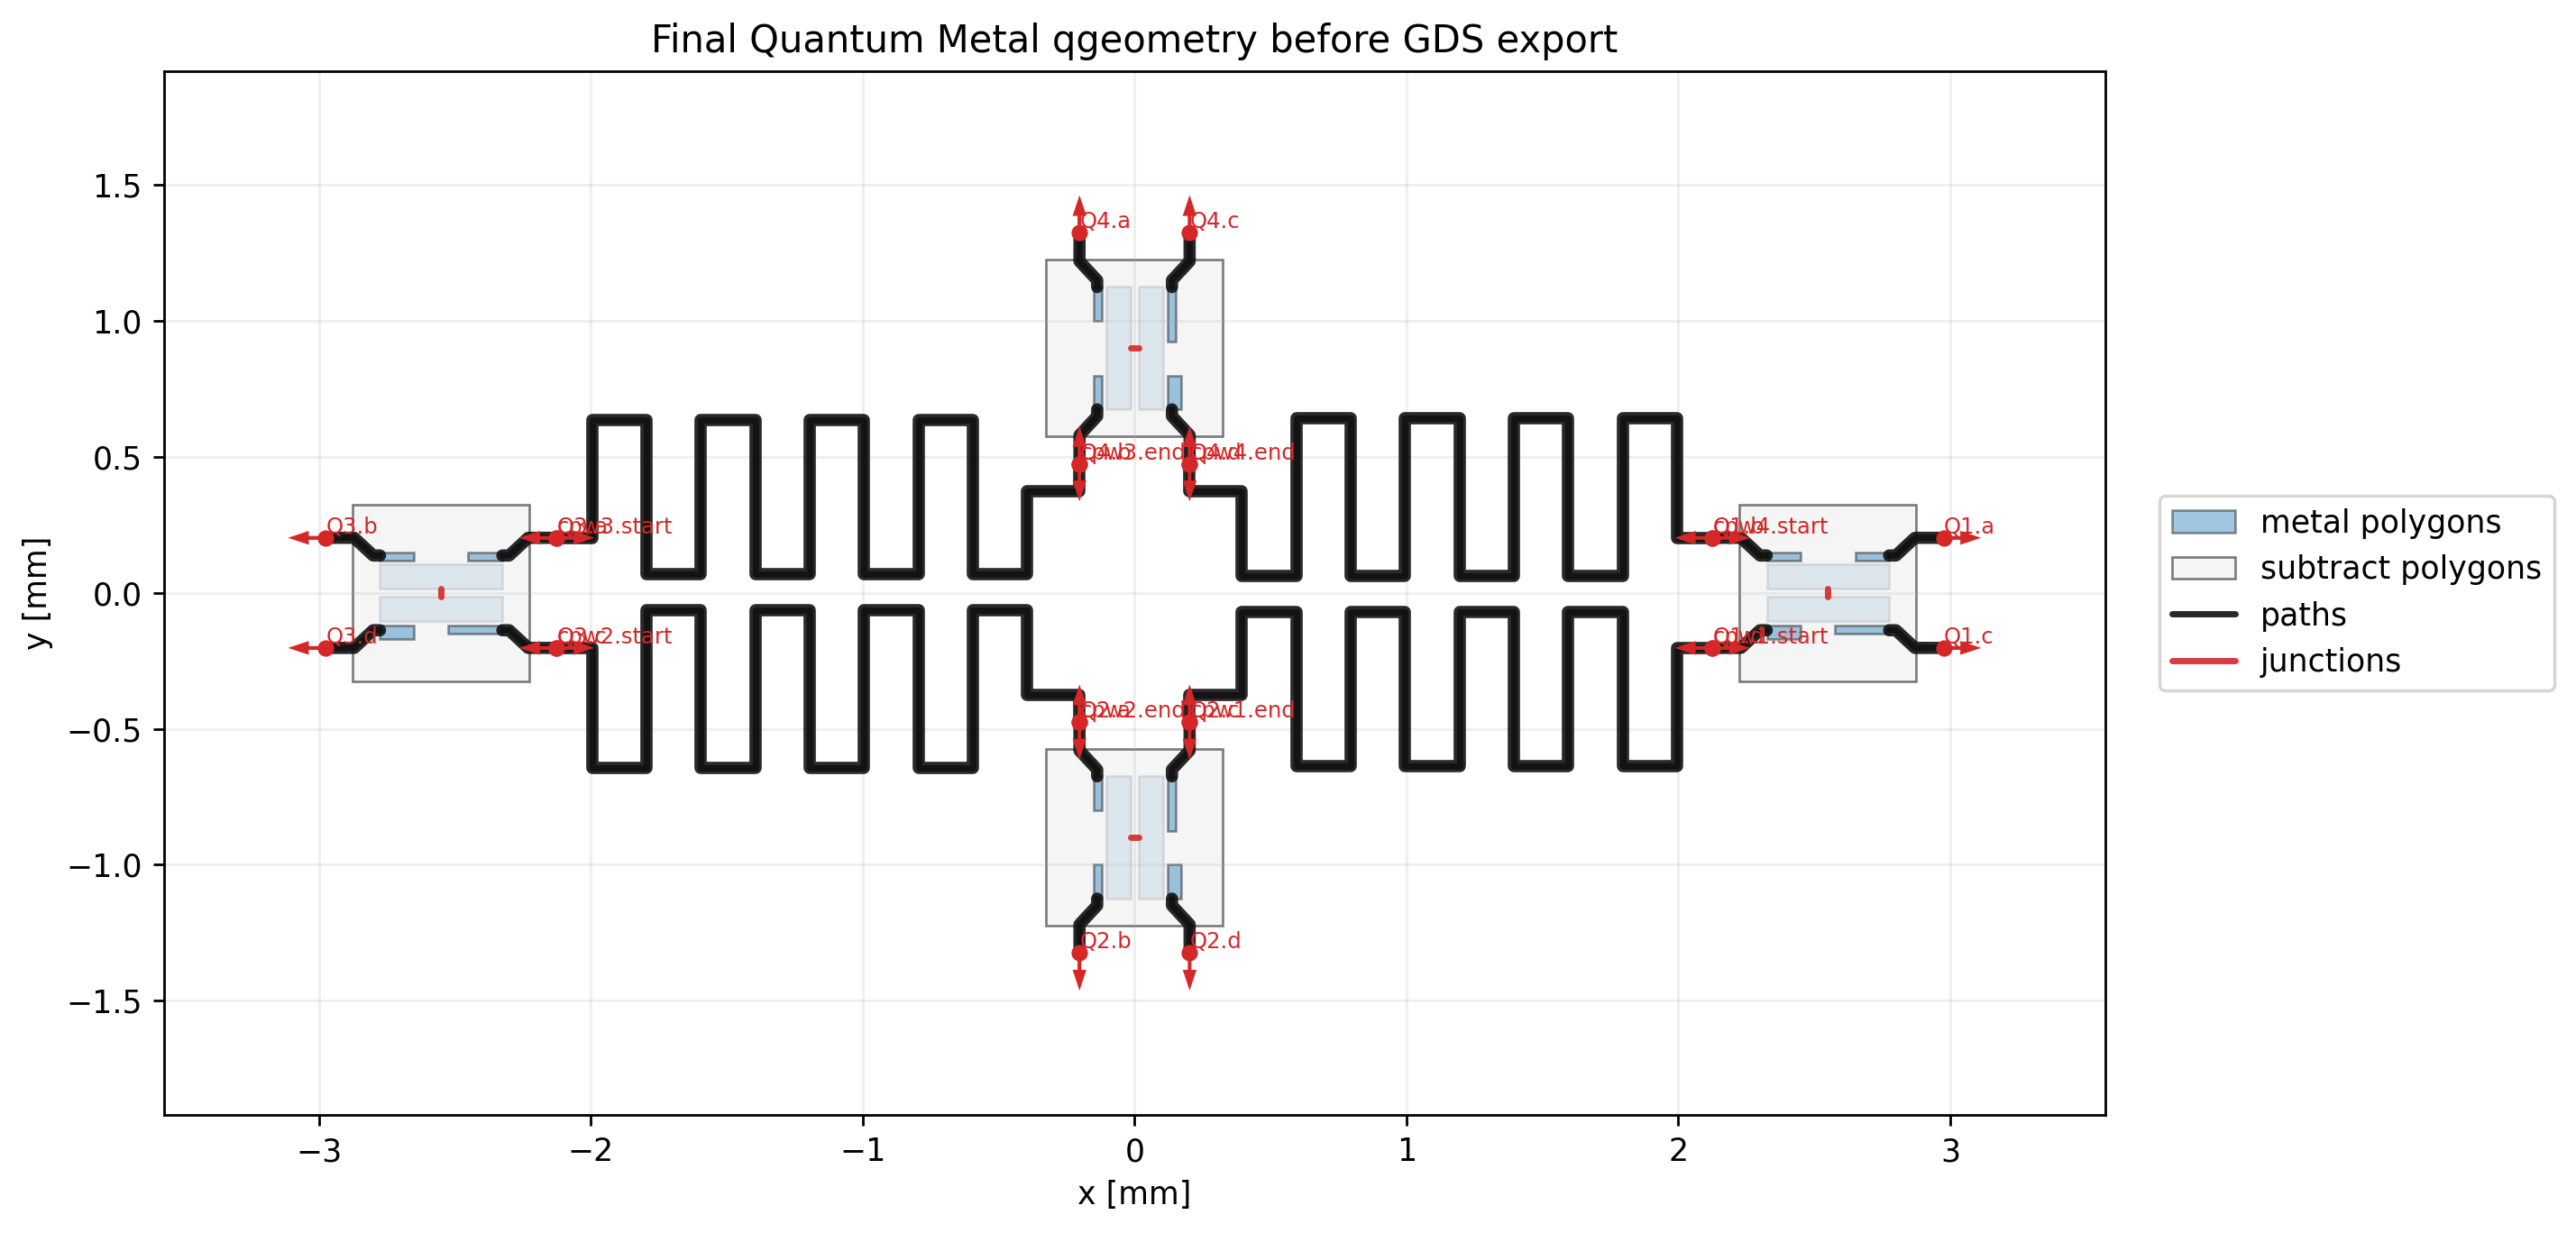

Wrote GDS: /content/quick_start_final_layout.gds
Polygon count by layer: {1: 24, 2: 4, 3: 40, 4: 4}
Path polygon generation methods: {'phidl': 40}
Path smoothing radius in design units: 0.09 corner style: euler


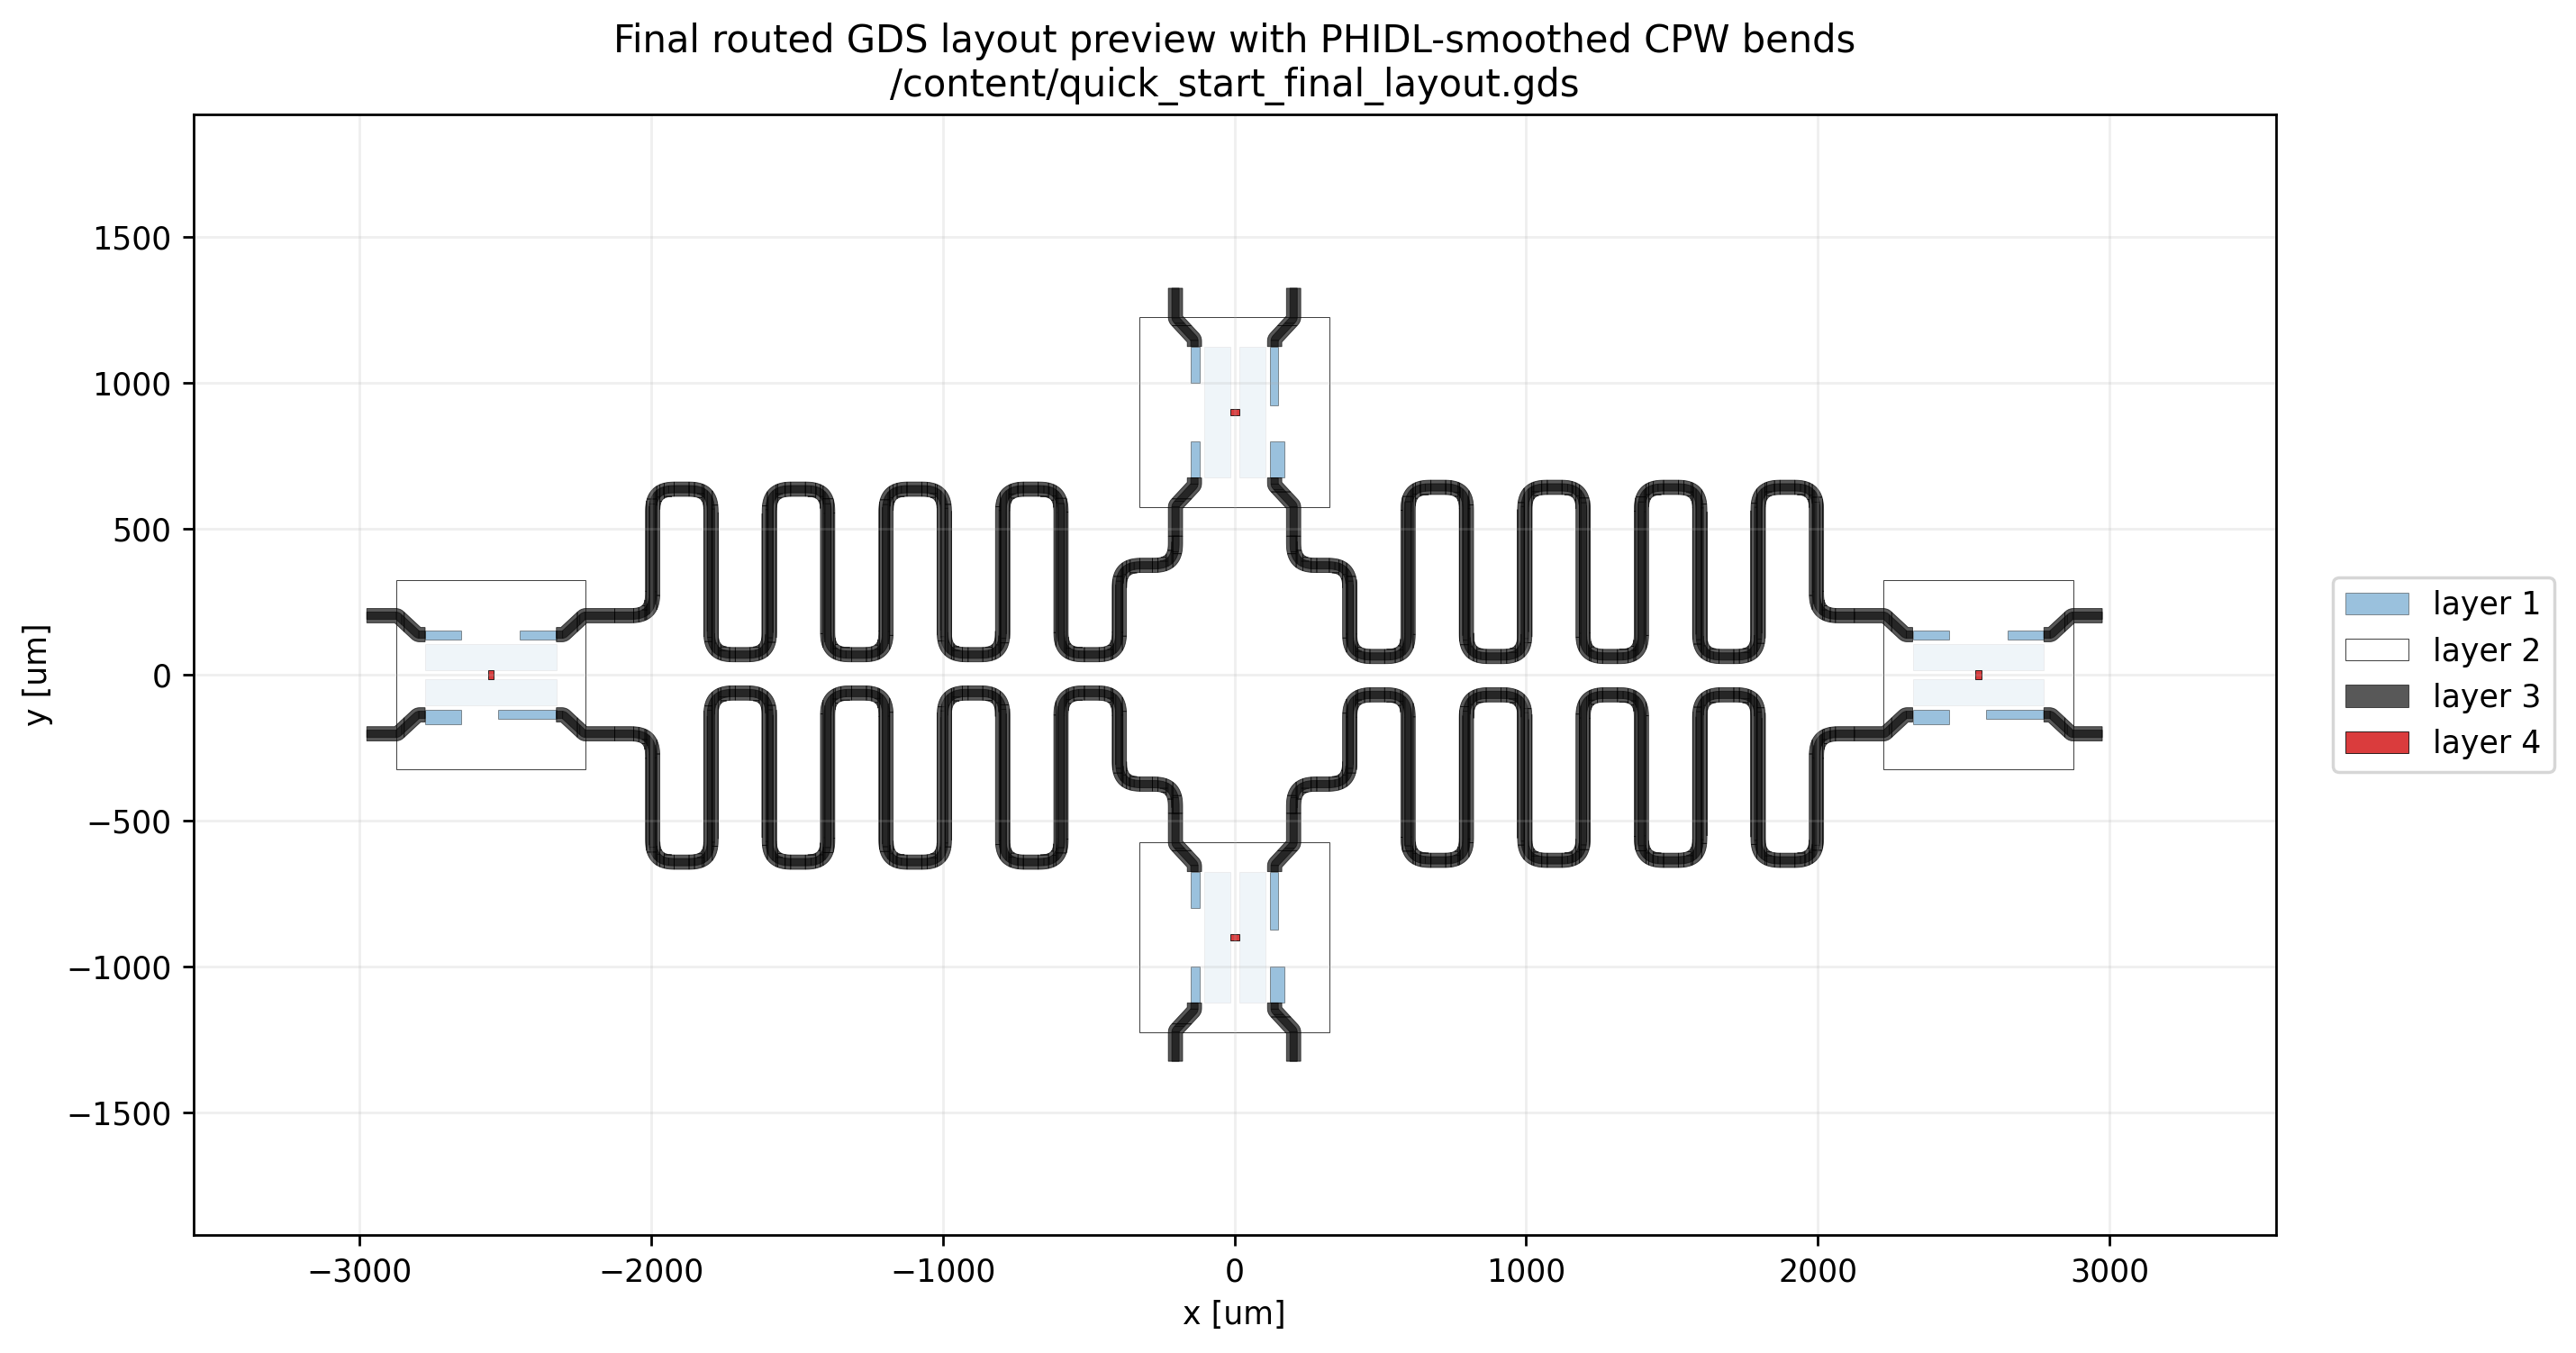

qiskit_metal import path: /content/qiskit-metal/src/qiskit_metal/__init__.py
qiskit_metal git commit: unknown
Download the GDS from Colab file browser: /content/quick_start_final_layout.gds


In [ ]:
"""Run final checks, export a PHIDL-smoothed routed GDS, and preview it."""

from pathlib import Path

import qiskit_metal as metal

# =============================================================================
# CONTROL KNOBS
# =============================================================================

RUN_OVERLAP_CHECK = False
SHOW_QGEOMETRY_TABLES = False
FINAL_GDS_PATH = Path("/content/quick_start_final_layout.gds")
SHOW_GDS_SMOOTHING_SETTINGS = True

print_heading("Final checks, PHIDL-smoothed GDS export, and GDS preview")

if SHOW_GDS_SMOOTHING_SETTINGS:
    show_table(summarize_gds_smoothing_settings(), "GDS path smoothing settings")

if RUN_OVERLAP_CHECK:
    try:
        from qiskit_metal.analyses.quantization import OverlapChecker

        overlap_table = OverlapChecker(design).check()
        show_table(overlap_table, "Overlap check results")
    except Exception as error:  # noqa: BLE001
        print(f"Overlap checker unavailable in this headless stack: {error}")
else:
    print("Overlap check skipped. Set RUN_OVERLAP_CHECK = True to run it.")

show_table(component_bounds_table(design), "Final design bounds")
show_table(qgeometry_summary(design), "Final qgeometry summary")

if SHOW_QGEOMETRY_TABLES:
    for table_name, table in design.qgeometry.tables.items():
        show_table(table, f"Global qgeometry table: {table_name}")

fig, _ = plot_design(
    design,
    title="Final Quantum Metal qgeometry before GDS export",
    show_pins=True,
    figure_size=WIDE_FIGURE_SIZE,
)
show_figure(fig)

gds_path = export_design_to_gds(
    design,
    output_path=FINAL_GDS_PATH,
    top_cell_name=GDS_TOP_CELL_NAME,
    source_units_to_um=GDS_SOURCE_UNITS_TO_UM,
    use_phidl_smoothing=GDS_USE_PHIDL_SMOOTHING,
    path_smooth_radius=GDS_PATH_SMOOTH_RADIUS_DESIGN_UNITS,
    path_smooth_corner_style=GDS_PATH_SMOOTH_CORNER_STYLE,
)

fig, _ = preview_gds(
    gds_path,
    title="Final routed GDS layout preview with PHIDL-smoothed CPW bends",
    figure_size=WIDE_FIGURE_SIZE,
)
show_figure(fig)

package_file = Path(metal.__file__).resolve()
print("qiskit_metal import path:", package_file)
print("qiskit_metal git commit:", git_commit_for_package(package_file))
print(f"Download the GDS from Colab file browser: {gds_path}")